# MHealth Dataset Data Prep and EDA Workbook

## Table of Contents

This notebook is organized around the following steps:

0. Import Libraries & Data
1. Contextual Information
2. Preliminary EDA & Visualizations
3. The Approach
4. Data Preprocessing
5. Label Engineering
6. Data Splitting

## 0. Import Libraries & Data

A one-time block of code that should be run at the beginning of this notebook.

In [1]:
%pip install nbconvert


  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (4.1 kB)
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
Using cached rpds_py-0.30.0-cp313-cp313-macosx_11_0_arm64.whl (358 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [nbconvert]16 [nbconvert]oup4]
Note: you may need to restart the kernel to use updated packages.


In [21]:
import csv
import sqlite3
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import classification_report
from scipy import signal
from mh_database import get_connection
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display
from matplotlib import animation
from scipy.signal import find_peaks, butter, filtfilt
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['animation.embed_limit'] = 50

At this point, the individual raw MHealth log files have been read and written into one large database (db) file. The following block of code establishes a connection to the database, and reads the dataset into a DataFrame. Runtime should be around 15 seconds.

In [2]:
conn = get_connection()
df = pd.read_sql("SELECT * FROM sensor_data ORDER BY subject_id ASC", conn)
conn.close()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1211745 entries, 0 to 1211744
Data columns (total 26 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1211745 non-null  int64  
 1   subject_id        1211745 non-null  int64  
 2   x_accel_chest     1211745 non-null  float64
 3   y_accel_chest     1211745 non-null  float64
 4   z_accel_chest     1211745 non-null  float64
 5   ecg_l1            1211745 non-null  float64
 6   ecg_l2            1211745 non-null  float64
 7   x_accel_l_ankle   1211745 non-null  float64
 8   y_accel_l_ankle   1211745 non-null  float64
 9   z_accel_l_ankle   1211745 non-null  float64
 10  x_gyro_l_ankle    1211745 non-null  float64
 11  y_gyro_l_ankle    1211745 non-null  float64
 12  z_gyro_l_ankle    1211745 non-null  float64
 13  x_magnet_l_ankle  1211745 non-null  float64
 14  y_magnet_l_ankle  1211745 non-null  float64
 15  z_magnet_l_ankle  1211745 non-null  float64
 16  

There are a total of 1,211,745 entries in the dataset, for a total of 10 research subjects. There are no null values.

## 1. Contextual Information

The dataset contains over a million rows of sensor information. It is important to be able to know how to interpret the sensor data values. I refer to the dataset documentation for a lot of this section, as well as some auxiliary online research.

### Experimental Set Up  

The dataset comprises of body motion and vital (namely ECG) sign recordings for ten volunteers of diverse profile. These ten volunteers performed 12 physical activities, labeled in the dataset as follows. Each activity was done for 1 minute, except for activities 6, 7, 8, and 12. Those activities were carried out as 20 reps per activity.

| **Label** |        **Activity**       |
|:---------:|:-------------------------:|
|     0     |       Null Class      |
|     1     |       Standing Still      |
|     2     |    Sitting and Relaxing   |
|     3     |         Lying Down        |
|     4     |          Walking          |
|     5     |      Climbing Stairs      |
|     6     |    Waist Bends Forward    |
|     7     | Frontal Elevation of Arms |
|     8     | Knees Bending (Crouching) |
|     9     |          Cycling          |
|     10    |          Jogging          |
|     11    |          Running          |
|     12    |   Jump (Front and Back)   |

Shimmer2 [BUR10] wearable sensors were used for all of the recordings. The sensors were placed on the subject's chest, right wrist, and left ankle.

The sensor positioned on the chest also provides 2-lead ECG measurements, which was not used for the development of the recognition model in the original publication, but will be used for model training in this project. 

All sensor modalities were recorded at a sampling rate of 50Hz, meaning a 5-second window is 250 rows. The activities were collected in an out-of-lab environment with no constraints on the execution of activities, with the exception that the subject should try their best. 

Units are in m/s^2 for acceleration, deg/s for gyroscope, local µT for magnetometer, and mV for ECG data. 


### The Variables and How to Interpret Them

#### Acceleration Data

Sources:
https://www.phidgets.com/docs/Accelerometer_Guide

The motion sensor gives 3-axis acceleration data: X, Y, and Z. The more positive the value is, the faster the arm/ankle is moving in the positive direction on the respective axis, and likewise for negative values. 
In order to interpret these values, it is important to understand what they mean. 

The accelerometer measures linear acceleration, but is always influenced by gravity. If the sensor is sitting perfectly still on a table, the acceleration magnitude will be approximately 9.81m/s^2. This allows me to calculate tilt, because if the Z-axis reads 9.81m/s^2, the sensor is flat, but if the X-axis reads 9.81m/s^2, it's standing on its side. Sharp movements, such as jumping, or kicking a ball, will result in a high magnitude. The best proxy for intensity from this data is standard deviation. High variance in acceleration should correlate with high physical exertion. 


#### Gyroscope Data

Sources: 
https://www.phidgets.com/docs/Gyroscope_Guide

Gyroscopes measure the rate at which the sensor is rotating (angular velocity). By adding up or integrating all of the readings of angular velocity over time, I can track the angle of rotation from where the sensor started. However, unlike magnetometers and accelerometers, there is no fixed frame of reference that can be measured by the gyroscope itself to determine a starting angle. Additionally, unlike the accelerometer, it is not affected by gravity. 

A reading of 0deg/s means that the device is not rotating, even if the device is moving linearly. High values, on the other hand, indicate rapid changes in posture or limb rotation, such as frontal elevation of arms. 

It is important to note that there is a drift problem in most gyroscopes. Errors will accumulate over time if data values are integrated to find an angle. Therefore, the other sensors are needed to "correct" the gyroscope data. 


#### Magnetometer Data

Sources: 
https://www.phidgets.com/docs/Magnetometer_Guide

The magnetometer measures the strength and direction of the magnetic field in µT. In a "clean" environment, it points toward Magnetic North, essentially acting as a  digital compass. By comparing x and y magnetic values, it's possible to determine which direction the user is facing. 

The magnetometer is the only sensor that can differentiate between certain movements and directions. For example, if the user moves from a "Face North" squat to a "Face East" lunge, the magnetometer is the only sensor that will clearly show that 90 degree change in the global frame. 

It is important to note that because it measures µT, it is highly sensitive to its environment, namely magnets, speakers, or steel beams in a gym. It is likely to react to the environment as the user moves through it. 


#### ECG Data

Sources: 
https://geekymedics.com/understanding-an-ecg/

Whenever the direction of electrical activity moves towards a lead, a positive deflection is produced. As such, whenever the direction of electrical activity moves away from a lead, a negative deflection is produced. Lead 2 shows the most positive deflection as it is the most closely aligned to the overall direction of electrical spread (Reference: https://geekymedics.com/wp-content/uploads/2023/10/Normal-Cardiac-Axis-600x338.jpg). Both L1 and L2 data will be used in the development of the model. 

## 2. Preliminary EDA & Visualizations

Let's look at the subject ID values.

In [5]:
df.subject_id.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Note: Keep in mind that subject IDs are zero-indexed in the database. That is, subject 1's subject ID is 0.

How about the distribution of subject ID value counts? Are there any subjects who have significantly more data than others?

In [6]:
df.subject_id.value_counts().sort_index()

subject_id
0    161280
1    130561
2    122112
3    116736
4    118808
5     98304
6    104448
7    129024
8    134168
9     96304
Name: count, dtype: int64

Subjects 5 and 9 have noticeably less data points than the rest of the subjects in the dataset. This doesn't necessarily mean that this is an imbalanced dataset, unless the data values for the activity label (the variable of interest) is imbalanced. Let's check this:

In [7]:
df.activity_label.value_counts().sort_index()

activity_label
0     869180
1      30720
2      30489
3      30720
4      30720
5      30720
6      27916
7      29441
8      29337
9      30720
10     30720
11     30720
12     10342
Name: count, dtype: int64

There are more than 20x the amount of data points for activity label 0 than for activities 1-11. Activity 12 has the least amount of data points; only 10,342. 

According to the MHealth Dataset documentation, the label is 0 for the null class. Let's see what this means:

In [8]:
# The motion, magnetometer, and gyroscope data for the null class:
df[df['activity_label'] == 0].head()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
0,1,0,-9.8184,0.009971,0.29563,0.004186,0.004186,2.1849,-9.6967,0.63077,...,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,-2.35000,-1.610200,-0.030899,0
1,2,0,-9.8489,0.524040,0.37348,0.004186,0.016745,2.3876,-9.5080,0.68389,...,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,-2.16320,-0.882540,0.326570,0
2,3,0,-9.6602,0.181850,0.43742,0.016745,0.037677,2.4086,-9.5674,0.68113,...,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,-1.61750,-0.165620,-0.030693,0
3,4,0,-9.6507,0.214220,0.24033,0.079540,0.117220,2.1814,-9.4301,0.55031,...,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,-1.07710,0.006945,-0.382620,0
4,5,0,-9.7030,0.303890,0.31156,0.221870,0.205130,2.4173,-9.3889,0.71098,...,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,-0.53684,0.175900,-1.095500,0


In [9]:
# The motion, magnetometer, and gyroscope data for activity 11 (running):
df[df['activity_label'] == 11].head()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
98816,98817,0,-6.8405,1.1151,0.8372,-0.69492,-1.7206,-3.95080,-19.1540,12.2940,...,-19.67000,1.2327,-3.73000,-0.78431,-0.48665,0.58405,6.0901,124.2700,73.969,11
98817,98818,0,-2.3256,1.6357,1.7788,-0.68655,-1.4108,9.41860,-11.6420,-15.6960,...,-13.87000,6.6378,0.77981,-0.78431,-0.48665,0.58405,21.9650,95.9980,111.750,11
98818,98819,0,5.1427,3.9738,1.7050,-1.84200,-2.4113,19.52100,-6.9617,-12.0070,...,-9.19500,11.6860,3.60510,-0.78431,-0.48665,0.58405,38.3520,47.0350,132.070,11
98819,98820,0,7.7713,4.3640,-3.3757,-2.49500,-3.2988,-2.53520,-9.3031,-1.5947,...,-5.13840,14.9990,3.94790,-0.94510,-0.35729,0.38578,41.3690,7.6148,149.490,11
98820,98821,0,5.0924,5.9866,-7.7138,-1.92990,-3.7300,0.75023,-19.1470,11.9980,...,-0.97921,15.0400,4.96030,-0.94510,-0.35729,0.38578,40.4200,2.5166,165.040,11


### The Null Class Problem

There are large differences between the values shown above. There are several implications for this project: 

1. Class Imbalance: The biggest effect of this "null class", which makes up a very big percentage of the total data. I need to be cautious in emphasizing not letting the model train on this data, and preprocess so that it can be treated as "noise" or kind of "nothing" data. If not, the model will probably get very good at predicting "doing nothing" based on sheer probability.
2. High Variance/Unpredictability: Unlike rhythmic activities such as running or climbing stairs, the null class is chaotic. That is, because there is no defined activity, it can range from staying perfectly still, to erratic fidgeting or leg shaking. 
3. False Exertion: The goal of the model is to be able to predict the exertion level of the user based on sensor data. If subjects in the null class are fidgeting or moving the sensor, the vector magnitude of the accelerometers may spike. I need to take the appropriate measures such that the model doesn't mistakenly label these activities as high exertion levels. This is where the ECG data is important to incorporate into the model.

How can the class imbalance be addressed? There are a few options to pursue at this point: 
- Drop the null class. This option is useful if the focus is purely on fitness mapping, as the model can train and predict only on known exertion types.
- Keep the null class, but treat it as baseline exertion (e.g. level 0 exertion). This is probably a more realistic approach because the user isn't always working out, but more difficult because the user's specific activity is not known nor controlled.
- Use the ECG data to validate the null class. If the activity label is 0 but the ECG HR data is high, that's a likely "recovery period". If the HR is low, then it could be considered as a true idle. 

Let's try to understand how the null class behaves and varies as compared to a low exertion level activity (such as standing still: 1) and a high exertion level activity (such as running: 11). 

In [10]:
# Null class
null_class = df[df['activity_label'] == 0].copy()
null_class.describe()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
count,8.691800e+05,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,...,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.000000,869180.0
mean,5.994429e+05,4.188982,-8.932388,-0.244002,-1.097303,-0.008574,-0.003196,1.372589,-9.942858,-1.057254,...,-3.816227,-5.810996,2.402283,-0.307129,-0.486630,0.221647,0.446673,0.434293,-0.521577,0.0
std,3.524990e+05,2.967277,3.116112,1.813535,3.070122,0.707794,0.669674,3.656883,3.659095,5.016011,...,4.232406,5.405107,3.753359,0.515701,0.557882,0.577047,23.077390,34.646803,63.758268,0.0
min,1.000000e+00,0.000000,-22.306000,-20.158000,-18.391000,-8.619600,-8.619600,-22.126000,-19.613000,-19.364000,...,-22.361000,-18.972000,-18.239000,-8.339200,-3.570800,-2.689700,-317.930000,-363.900000,-717.550000,0.0
25%,2.880018e+05,1.000000,-9.843300,-1.266800,-2.603300,-0.246990,-0.196760,0.130430,-10.252000,-2.434100,...,-6.369400,-9.338700,0.129900,-0.713730,-0.926080,-0.303880,-6.205825,-10.466000,-15.054000,0.0
50%,6.068795e+05,4.000000,-9.398600,-0.374770,-0.865480,-0.071167,-0.041863,1.290100,-9.695800,-0.119300,...,-3.185600,-7.340300,1.980000,-0.378430,-0.648870,0.252160,0.368205,0.348010,-0.589615,0.0
75%,9.090642e+05,7.000000,-8.199900,0.632450,0.599853,0.159080,0.154890,2.472700,-9.233600,1.093700,...,-1.438800,-2.602900,4.791700,0.045098,-0.133470,0.741380,7.311300,10.758000,14.189250,0.0
max,1.211745e+06,9.000000,19.078000,20.917000,25.534000,8.514900,8.519100,20.054000,21.059000,24.773000,...,19.864000,22.191000,25.735000,3.319600,1.556500,2.750000,251.150000,337.760000,656.860000,0.0


In [11]:
# Low exertion level class: standing still (1)
standing_class = df[df['activity_label'] == 1].copy()
standing_class.describe()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
count,3.072000e+04,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,...,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.0
mean,5.947317e+05,4.500000,-9.613480,-0.699418,0.141333,0.014754,-0.000798,0.880712,-9.692594,1.090515,...,-2.440308,-9.303726,1.139256,-0.340318,-0.746303,0.172305,0.355636,0.344874,-0.553059,1.0
std,3.440065e+05,2.872328,0.246040,0.660306,1.394403,0.463791,0.317936,0.951944,0.135990,0.574736,...,0.750628,0.250751,0.959020,0.472812,0.227104,0.455742,0.770587,1.793016,1.128690,0.0
min,6.657000e+03,0.000000,-10.951000,-2.597100,-2.654700,-1.595000,-1.276800,-1.806400,-10.584000,-1.016600,...,-4.876400,-10.438000,-1.616100,-0.907840,-1.110900,-0.543100,-9.893800,-30.916000,-14.096000,1.0
25%,2.979858e+05,2.000000,-9.769800,-1.172300,-0.609208,-0.142330,-0.117220,0.310645,-9.785100,0.567005,...,-3.008800,-9.492125,0.347485,-0.803920,-0.932240,-0.234910,0.170440,-0.019806,-1.077500,1.0
50%,5.942015e+05,4.500000,-9.659500,-0.829715,-0.104840,-0.071167,-0.041863,0.898125,-9.696200,1.065700,...,-2.652650,-9.316450,1.248850,-0.349020,-0.737165,0.161640,0.362660,0.354020,-0.707520,1.0
75%,8.630012e+05,7.000000,-9.518375,-0.101852,0.823525,0.037677,0.037677,1.568600,-9.602000,1.546725,...,-2.195800,-9.100100,1.799325,0.056863,-0.650920,0.418100,0.551180,0.887550,0.000103,1.0
max,1.149233e+06,9.000000,-8.419300,0.949660,4.296100,4.902100,3.457900,2.815100,-8.660900,3.218000,...,1.677700,-8.590800,3.242500,0.460780,-0.184800,0.995690,19.097000,57.527000,19.288000,1.0


In [12]:
# High exertion level class: running (11)
running_class = df[df['activity_label'] == 11].copy()
running_class.describe()

,id,subject_id,x_accel_chest,y_accel_chest,z_accel_chest,ecg_l1,ecg_l2,x_accel_l_ankle,y_accel_l_ankle,z_accel_l_ankle,...,x_accel_r_arm,y_accel_r_arm,z_accel_r_arm,x_gyro_r_arm,y_gyro_r_arm,z_gyro_r_arm,x_magnet_r_arm,y_magnet_r_arm,z_magnet_r_arm,activity_label
count,3.072000e+04,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,...,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.000000,30720.0
mean,6.626533e+05,4.500000,-7.481828,0.002838,-2.481333,-0.142393,-0.204459,3.629201,-12.291468,-3.443592,...,-7.672636,-4.719071,-0.666658,-0.534553,-0.032328,0.708951,-4.902108,14.126681,3.051872,11.0
std,3.407643e+05,2.872328,10.167910,5.045527,4.822459,1.739136,1.975032,9.174321,9.061575,11.692899,...,11.250424,11.765866,6.965302,0.301443,0.394119,0.473876,76.038963,60.440475,213.977805,0.0
min,9.881700e+04,0.000000,-22.438000,-20.188000,-18.392000,-8.619600,-8.619600,-22.146000,-19.619000,-19.373000,...,-22.015000,-18.972000,-18.238000,-1.111800,-1.141700,-0.924570,-319.030000,-354.420000,-702.570000,11.0
25%,3.660818e+05,2.000000,-19.065000,-3.023275,-4.588300,-0.703300,-0.556780,-0.824580,-19.187000,-15.068500,...,-20.594000,-15.539250,-4.630100,-0.764710,-0.227930,0.646550,-58.570750,-18.758500,-137.212500,11.0
50%,6.494975e+05,4.500000,-4.384950,-0.167305,-1.692200,-0.104660,-0.050235,3.701000,-16.470500,-3.497650,...,-7.779650,-7.544100,-0.875145,-0.564710,-0.006160,0.890090,-4.149050,13.906500,-8.124200,11.0
75%,9.674492e+05,7.000000,1.348200,2.885200,0.312652,0.468860,0.498170,8.862600,-7.227675,5.566950,...,0.810540,6.271175,3.107950,-0.339220,0.195070,1.010800,48.850750,49.436500,148.185000,11.0
max,1.198921e+06,9.000000,12.996000,20.927000,24.991000,8.506500,8.519100,20.024000,21.161000,25.015000,...,19.787000,21.865000,24.639000,0.613730,1.121100,1.185300,239.690000,331.910000,657.180000,11.0


The null class has a high standard deviation, but not as high as the high exertion level class. However, the null class' averages are closer to the low exertion level activity. 

What I could do is to combine options 2 and 3, and keep the null class and treat it as a level 0, baseline exertion (i.e. the user is not working out), and at the same time, use the ECG HR data to validate the null class. For example, if the sensor data and HR is high, the exertion could be classified as "recovery". 

Essentially, the idea is to combine sensor intensity with physiological data (heart rate) to differentiate between active movement, rest, and physiological stress, and generally categorize the null class into four groups:

| **Motion Intensity (accel)** | **Heart Rate** | **Classification** |                               **Logic**                              |
|:----------------------------:|:--------------:|:------------------:|:--------------------------------------------------------------------:|
|              Low             |       Low      |   Baseline (Idle)  |                 True Null: Sitting or standing still.                |
|             High             |       Low      |    Sensor Noise    |       False Exertion: Moving the sensor, but no cardio load.       |
|              Low             |      High      |      Recovery      | Afterburn: Heart rate is still high, but movement has stopped. |
|             High             |      High      |   Active Exertion  |           True Workout: Validates the High Exertion class.           |

Perhaps I could use the high motion intensity, high heart rate subgroup of the null class for model evaluation (in the validation phase). This will be further explored and addressed in section 6: Data Preprocessing. But for now, let's see how we can define our thresholds for the above subgroups.

Firstly, the heart rate threshold will be 100bpm, which is the upper boundary for a normal resting heart rate. Any heart rate values at or above 100bpm will be considered a high heart rate (for the purposes of this project). 

The motion intensity threshold is less straightforward. The definition of the threshold would depend on whether I want the eventual recommender system to be subject-dependent or subject-independent. The following are some pros and cons of each approach:

Subject-dependent:
- Pros: Highly accurate for the individual. Normalizes for differences in body movement style. 
- Cons: Doesn't scale. If a new user starts using the recommender system, the model won't know their specific threshold until it collects days worth of data. 

Subject-independent:
- Pros: Creates a "general" model that can predict exertion for a random person/stranger.
- Cons: Very noisy. Individual variations may "wash out" the signal, which is more so probable given that the volunteer subjects are of diverse build. 

For now, I will calculate thresholds on a subject-dependent basis in section 6. The development of a subject-independent model could be the next step. 

Let's shift the focus to correlations between the raw features. I'm interested in if there are any relatively high correlations between variables. Intuitively, there may be correlations between ECG data and acceleration data, but let's see if this is actually the case.

In [13]:
corr = df.corr()

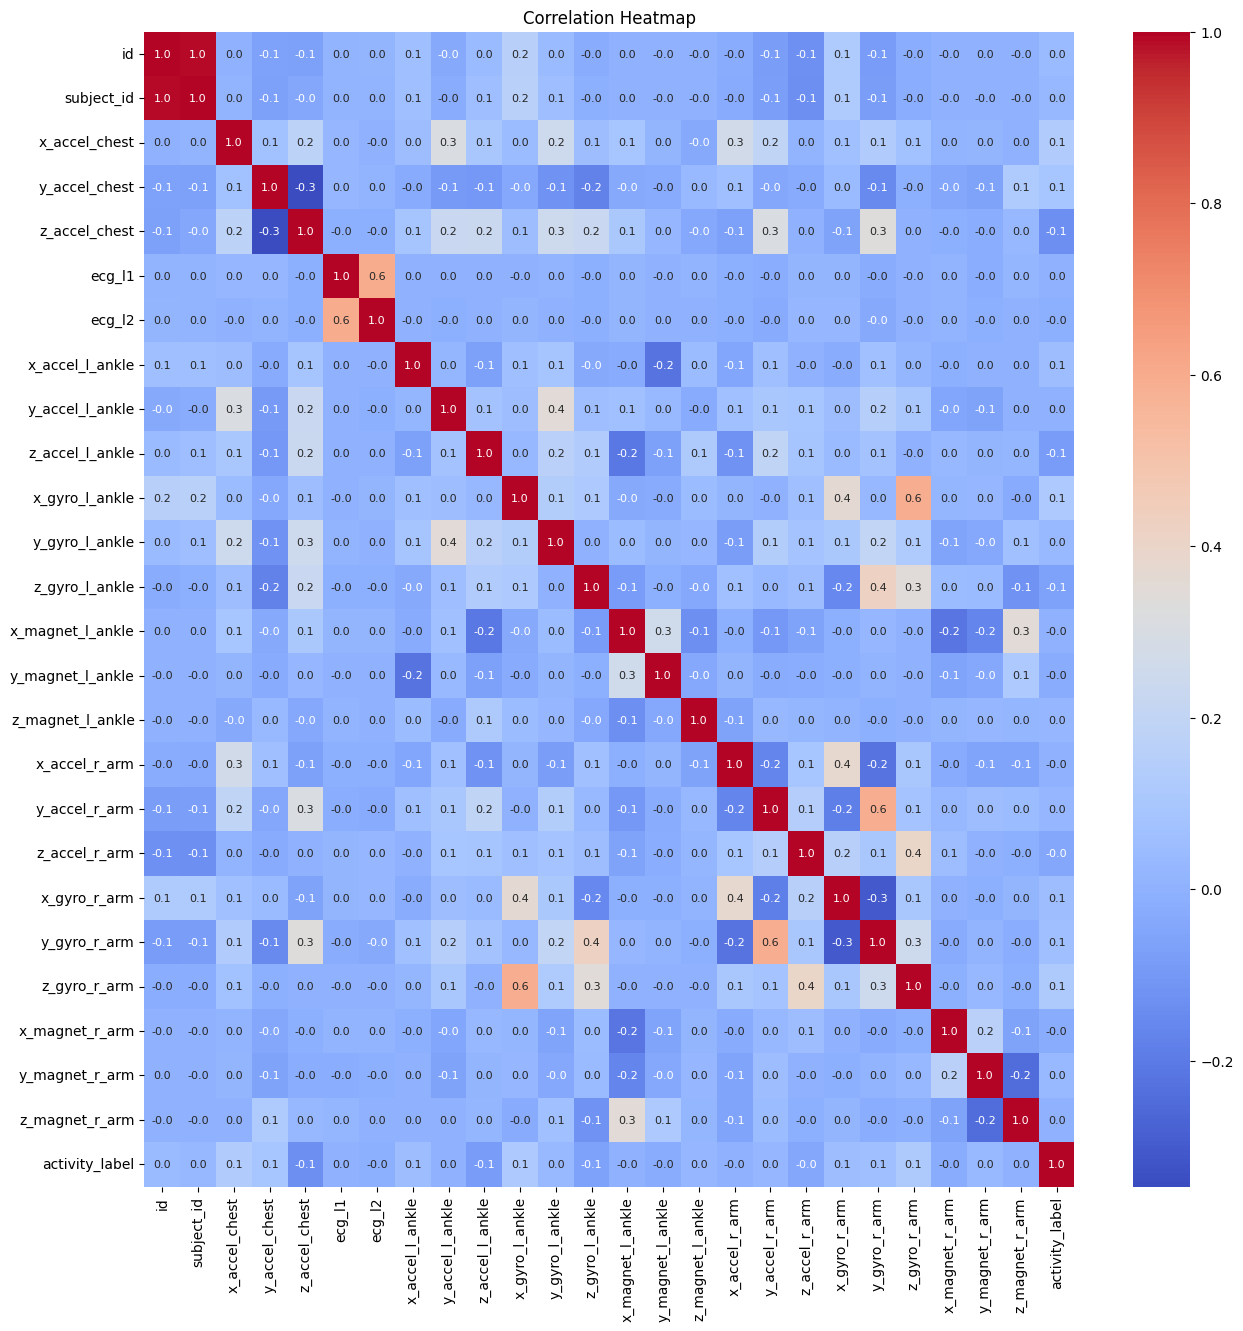

In [14]:
# Plot the correlation matrix
plt.figure(figsize = (15, 15))
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".1f", annot_kws = {"size": 8})
plt.title("Correlation Heatmap")
plt.show()

Interestingly, most of the variables are not strongly correlated with each other. Arm gyro data is moderately positively correlated with arm acceleration data. ECG data is not correlated with any other variables, which I guess makes sense because ECG data is rhythmic/cyclical and there is probably a time lag between ECG data and acceleration/gyro data. 

#### Subject Focus: Subject 1

Let's look at one subject first: subject 1. We will be looking at activity 11 (running) and specifically at the x acceleration of the chest motion sensor.

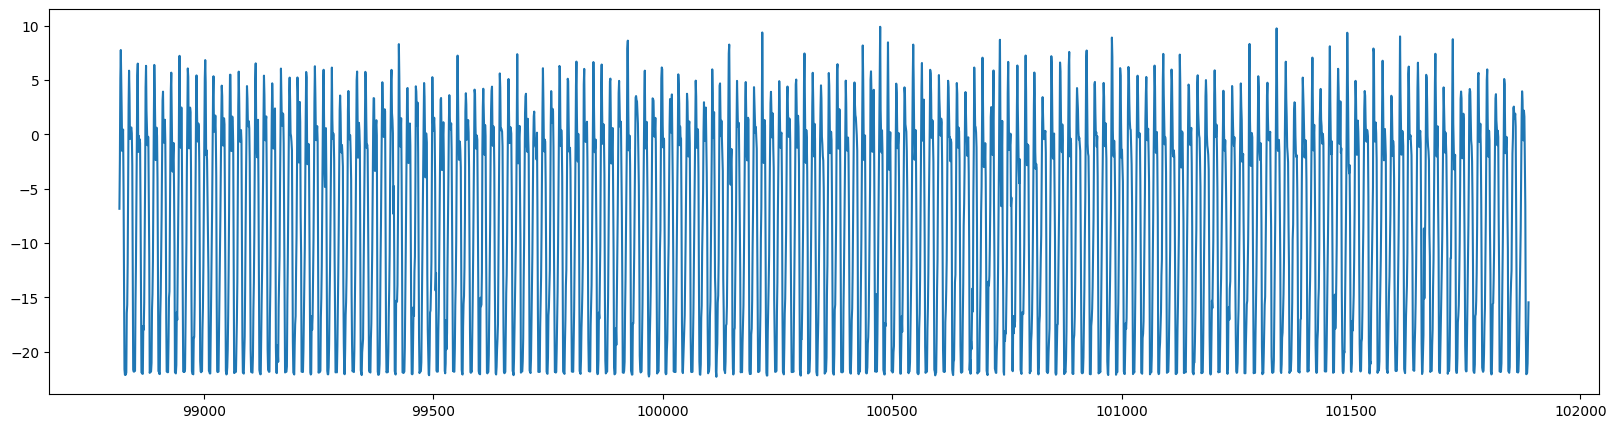

In [15]:
subject1_df = df[df["subject_id"] == 0].copy()

plt.figure(figsize = (20, 5))
plt.plot(subject1_df[subject1_df["activity_label"] == 11]["x_accel_chest"])
plt.show()

The x acceleration seems periodic, which aligns with intuition. 

It may be valuable to see how the data clusters for low intensity activities vs. high intensity activities. The following plots show each measurement's relative distributions.

In [3]:
# Define data groups dictionary
data_groups = {
    "chest_acceleration": [
        "x_accel_chest",
        "y_accel_chest",
        "z_accel_chest"
    ],
    "ecg": [
        "ecg_l1",
        "ecg_l2"
    ],
    "ankle_acceleration": [
        "x_accel_l_ankle",
        "y_accel_l_ankle",
        "z_accel_l_ankle"
    ],
    "ankle_gyro": [
        "x_gyro_l_ankle",
        "y_gyro_l_ankle",
        "z_gyro_l_ankle"
    ],
    "ankle_magnet": [
        "x_magnet_l_ankle",
        "y_magnet_l_ankle",
        "z_magnet_l_ankle"
    ],
    "arm_acceleration": [
        "x_accel_r_arm",
        "y_accel_r_arm",
        "z_accel_r_arm"
    ],
    "arm_gyro": [
        "x_gyro_r_arm",
        "y_gyro_r_arm",
        "z_gyro_r_arm"
    ],
    "arm_magnet": [
        "x_magnet_r_arm",
        "y_magnet_r_arm",
        "z_magnet_r_arm"
    ]
}

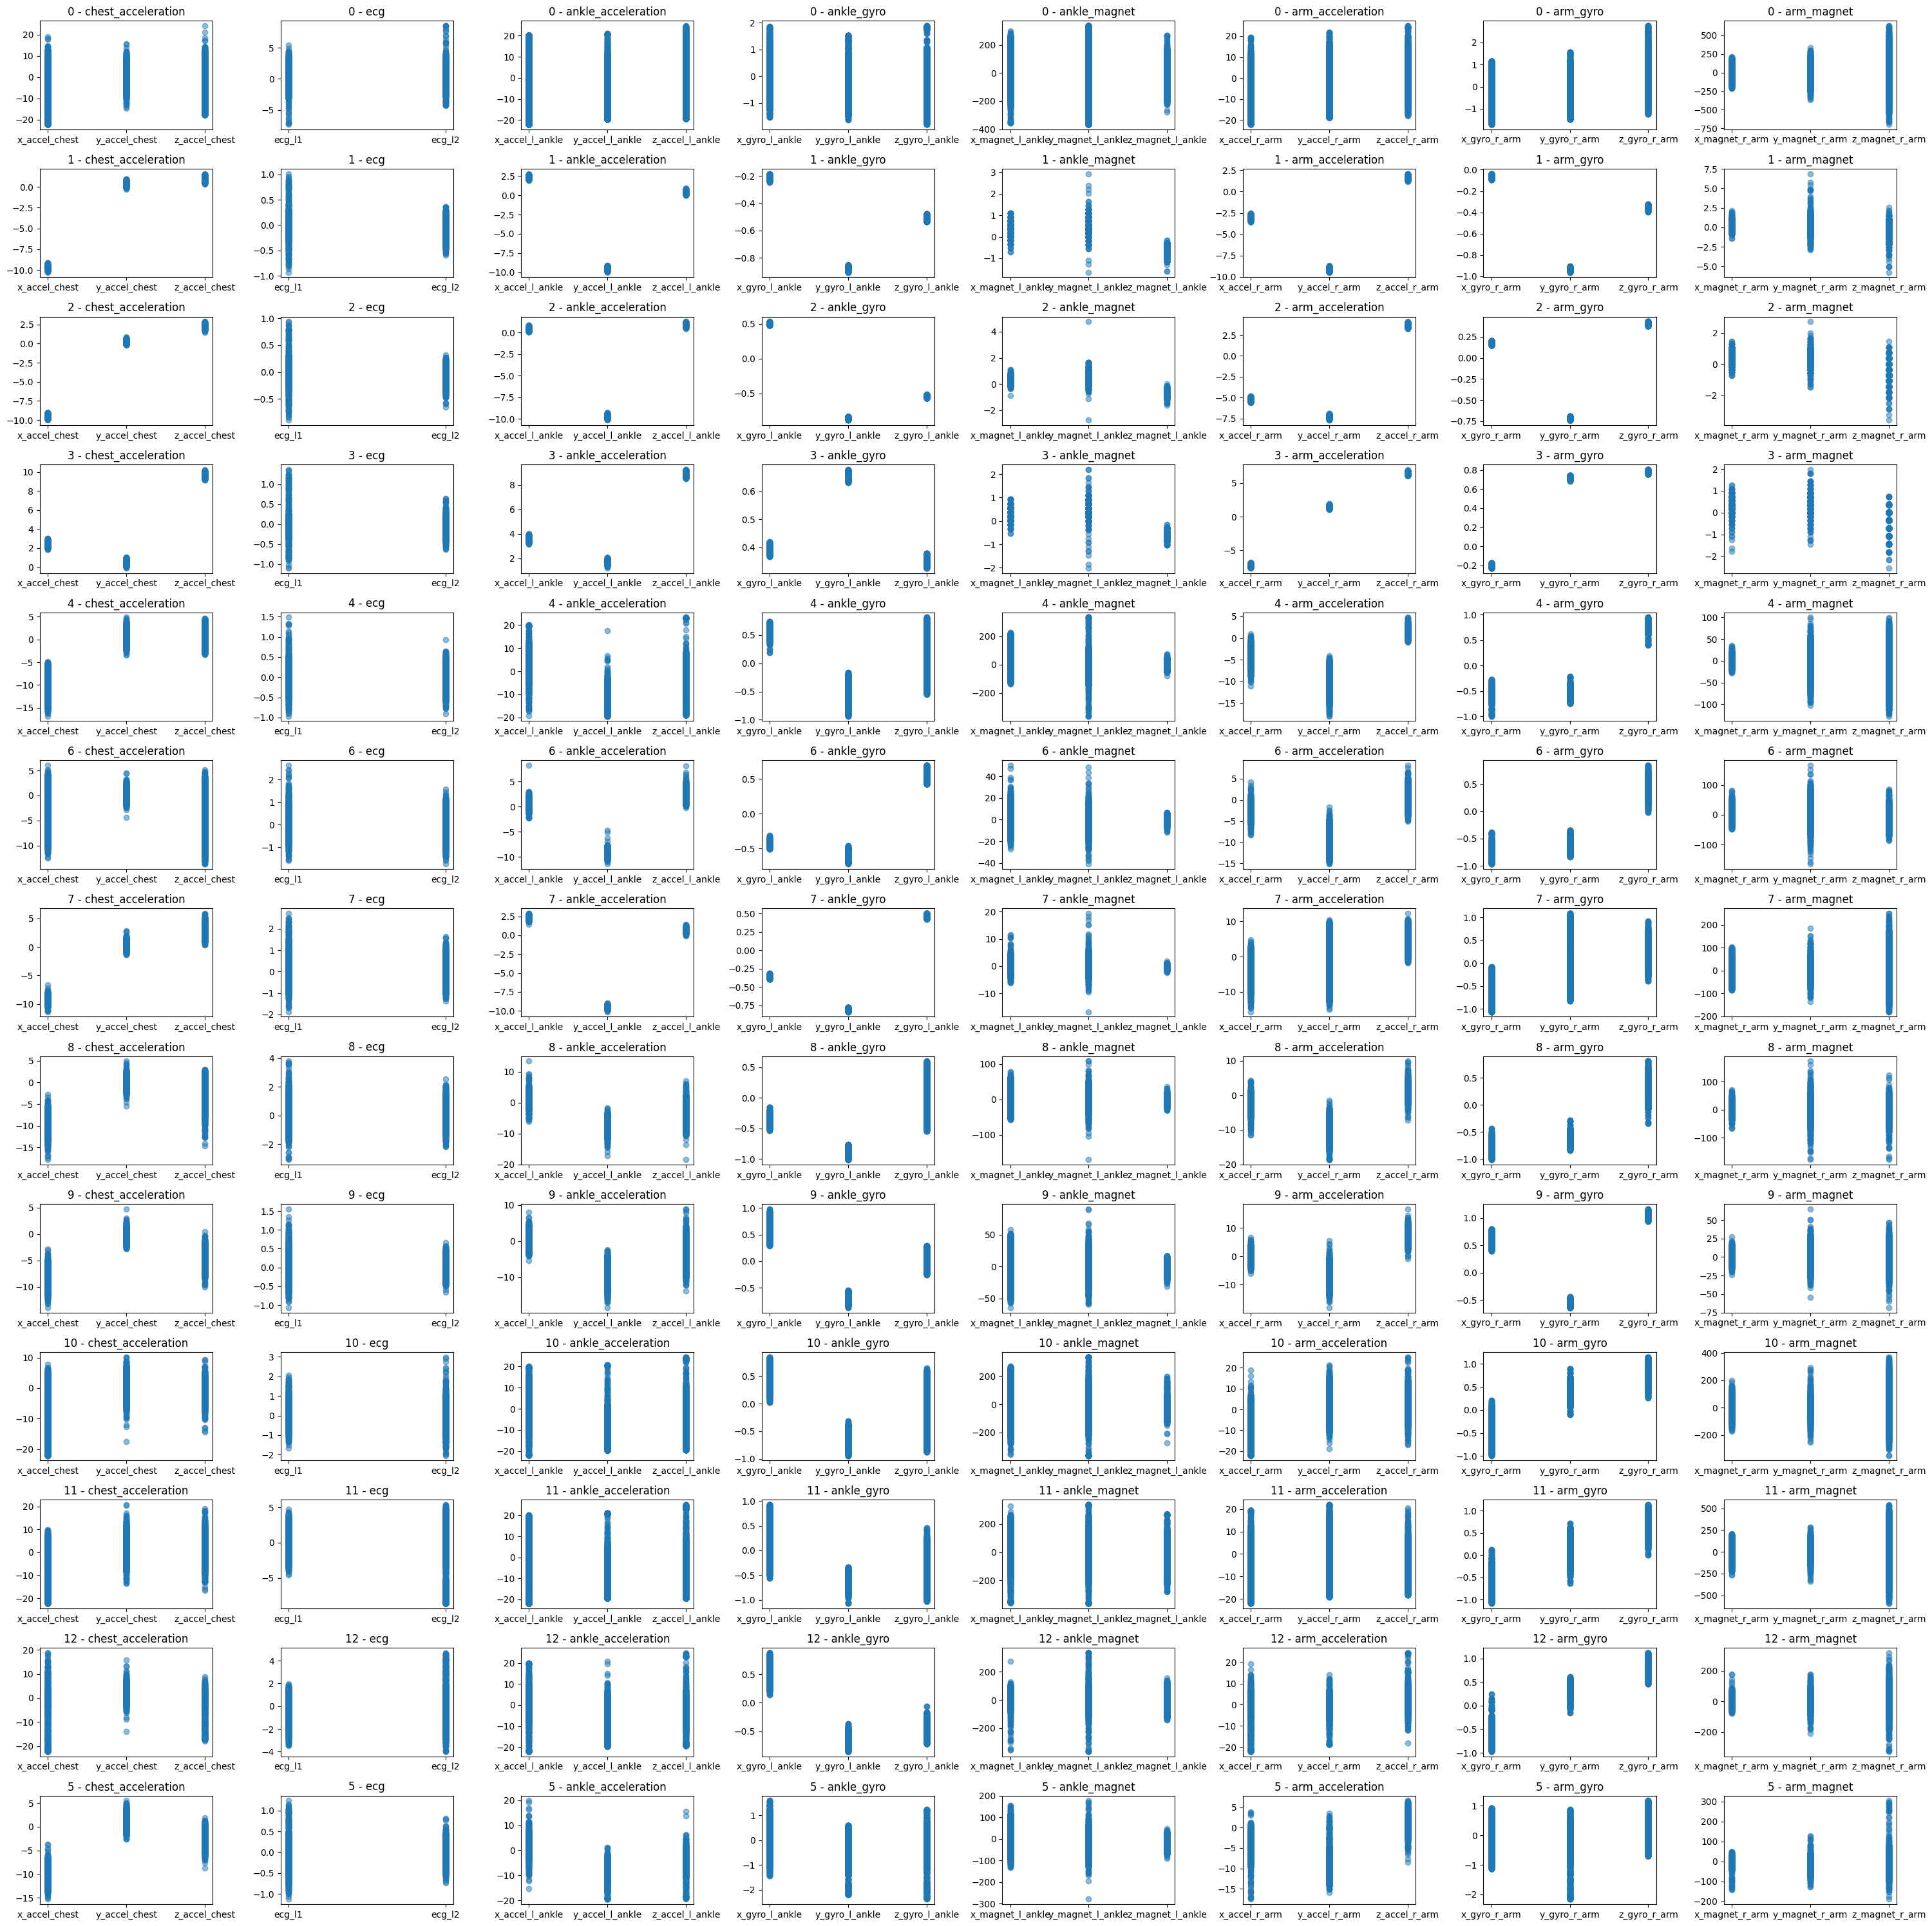

In [17]:
fig, axes = plt.subplots(
    len(subject1_df.activity_label.unique()),
    len(data_groups.keys()),
    figsize = (30, 30),
    sharex = False,
    sharey = False
)

activities = subject1_df.activity_label.unique()

for i, activity_label in enumerate(activities):
    activity_df = subject1_df[subject1_df["activity_label"] == activity_label]

    for j, group in enumerate(data_groups.keys()):
        subject_df = activity_df[list(data_groups[group])]
        data = pd.melt(subject_df, var_name = "Groups", value_name = "Values")
        axes[i, j].scatter(data["Groups"], data["Values"], alpha = 0.5)
        axes[i, j].set_title(f"{activity_label} - {group}")

plt.tight_layout()
plt.show()

## 3. The Approach

Sources:

A. M. Khan, Y. K. Lee and T. . -S. Kim, "Accelerometer signal-based human activity recognition using augmented autoregressive model coefficients and artificial neural nets," 2008 30th Annual International Conference of the IEEE Engineering in Medicine and Biology Society, Vancouver, BC, Canada, 2008, pp. 5172-5175, doi: 10.1109/IEMBS.2008.4650379. keywords: {Accelerometers;Vectors;Legged locomotion;Neural networks;Monitoring;Human activity recognition;Training;Testing;Biological neural networks;Real-time systems},

The paper cited above suggests that using autoregressive modeling coefficient values enhanced with SMA (Signal Magnitude Area) as well as TA (Tilt Angle) results in a highly accurate classification model. I will be adopting the technique of implementing SMA and TA into the features. 

Regarding the SMA, it is more useful in the context of this project because it computes the magnitude over a time window, integrating over time. Essentially, it accumulates activity instead of sampling it. Additionally, crude magnitude is instantaneous and is very sensitive to spikes and noise. 

[Talk about AR]

[Talk about CNN]

## 4. Data Preprocessing

In order to calculate reliable magnitude values from the motion sensor data, it is necessary to "clean" the noise in the data. A good way to do this is to apply the Butterworth filter in the scipy.signal.filtfilt function. Then, I'd be able to calculate the magnitudes of the accelerator, gyroscope, and magnetometer sensor data, effectively "combining" the 3-axis data into one feature. 

### The Butterworth Filter

The Butterworth filter is a signal processing filter that is designed to have a frequency response as flass as possible in the passband. It's primarily used to remove high-frequency noise while preserving low-frequency components. The scipy.signal module provides four different types of filters: `lowpass`, `highpass`, `bandpass`, and `bandstop`. 

`lowpass` and `bandpass` will be used in this project. 

#### The Low-Pass Filter

A low-pass filter basically removes high-frequency "jitter" or noise. It allows signals with a frequency lower than a specific cutoff frequency to pass and blocks everything higher. 

In the context of this project: human body movements such as walking or running are relatively slow, low-frequency events. However, sensors produce high-frequency electronic noise or "vibrations". Therefore, the low-pass filter will be used on the accelerometer, gyroscope, and magnetometer data. The only difference is that the magnetometer is incredibly sensitive to local magnetic interference, which causes the orientation to drift or flutter even if the subject isn't moving or changing orientation much. Therefore, the low-pass frequency threshold will be very low for the magnetometer, as compared to that of the accelerometer and gyroscope. 

#### The Band-Pass Filter

The band-pass filter allows frequencies within a specific range/band to pass, while blocking frequencies that are either too low or too high. Basically, it isolates a specific "middle" section of the signal. This is essential for cleaning ECG data, because it removes baseline wander on the low end, and muscle noise or power line interference on the high end. As a result, it centers the heartbeat signal and makes the R-peaks much easier to detect later on. 

How do I find out which cutoff frequencies should be used for the accelerometer, gyroscope, magnetometer, and ECG respectively? 

Let's look at the behavior of the acceleration, rotation, orientation, and ECG data for the chest, arm, and ankle respectively. I'll look at the data for standing (L1) and running (L11) to get an idea of low and high intensity activities.

### Arm

In [18]:
arm_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "arm" in group]

# Include only standing still and running activities
arm_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]


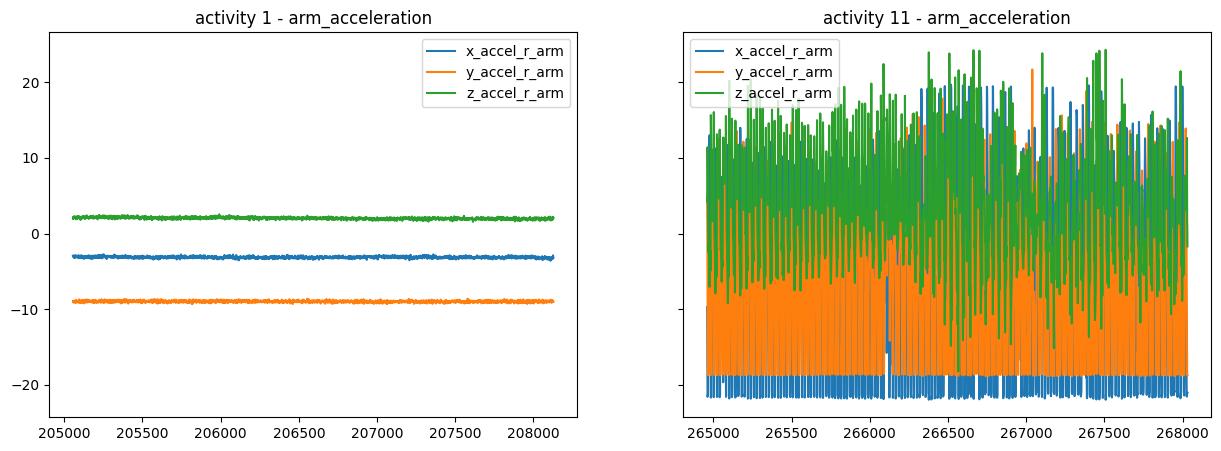

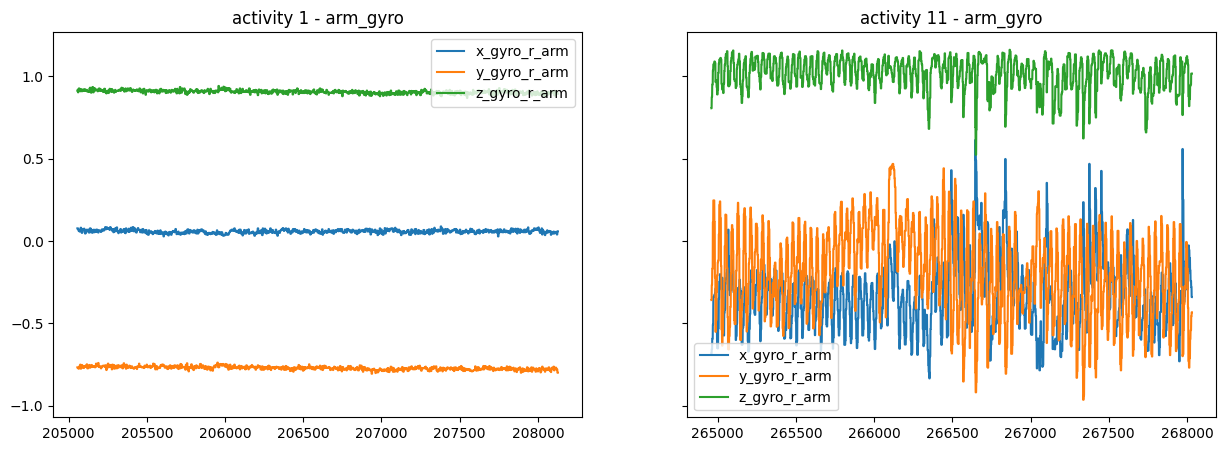

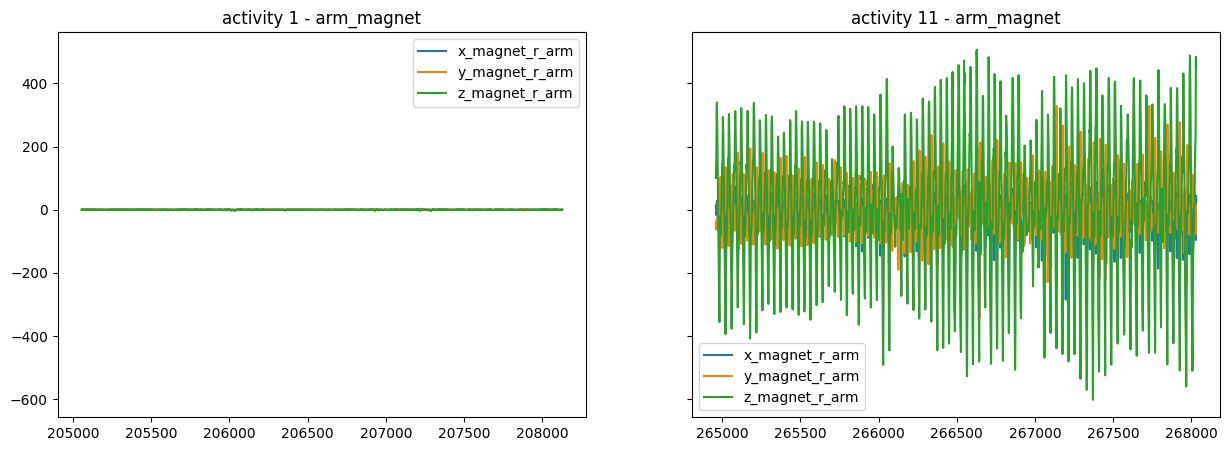

In [19]:
subject_id = 1

for group, measurements in arm_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    arm_subset = arm_df[columns]
    
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey = True)

    for i, activity in enumerate([1, 11]):
        arm_subsubset = arm_subset[(arm_subset["activity_label"] == activity) & (arm_subset["subject_id"] == subject_id)]
        axes[i].plot(arm_subsubset[measurements])
        axes[i].legend(measurements)
        axes[i].set_title(f"activity {activity} - {group}")

### Chest

In [20]:
chest_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "chest" in group]

# Include only standing still and running activities
chest_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]

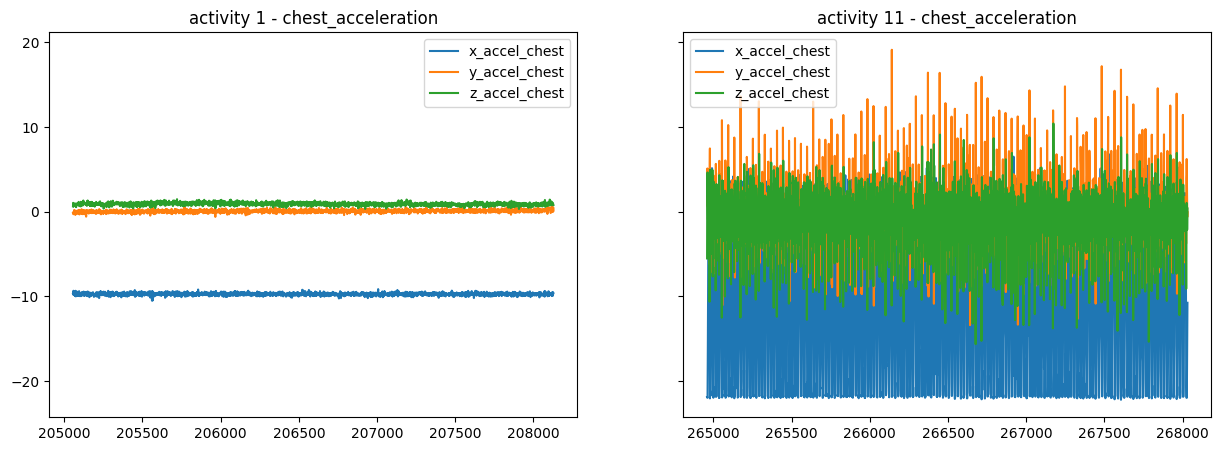

In [21]:
subject_id = 1

for group, measurements in chest_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    chest_subset = chest_df[columns]
    
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey = True)

    for i, activity in enumerate([1, 11]):
        chest_subsubset = chest_subset[(chest_subset["activity_label"] == activity) & (chest_subset["subject_id"] == subject_id)]
        axes[i].plot(chest_subsubset[measurements])
        axes[i].legend(measurements)
        axes[i].set_title(f"activity {activity} - {group}")

### Ankle

In [22]:
ankle_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "ankle" in group]

# Include only standing still and running activities
ankle_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]

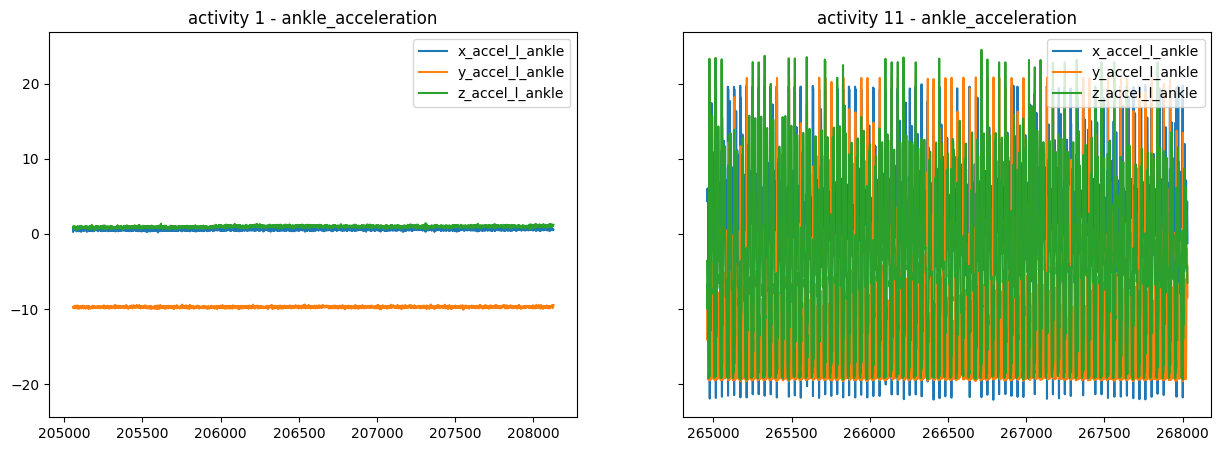

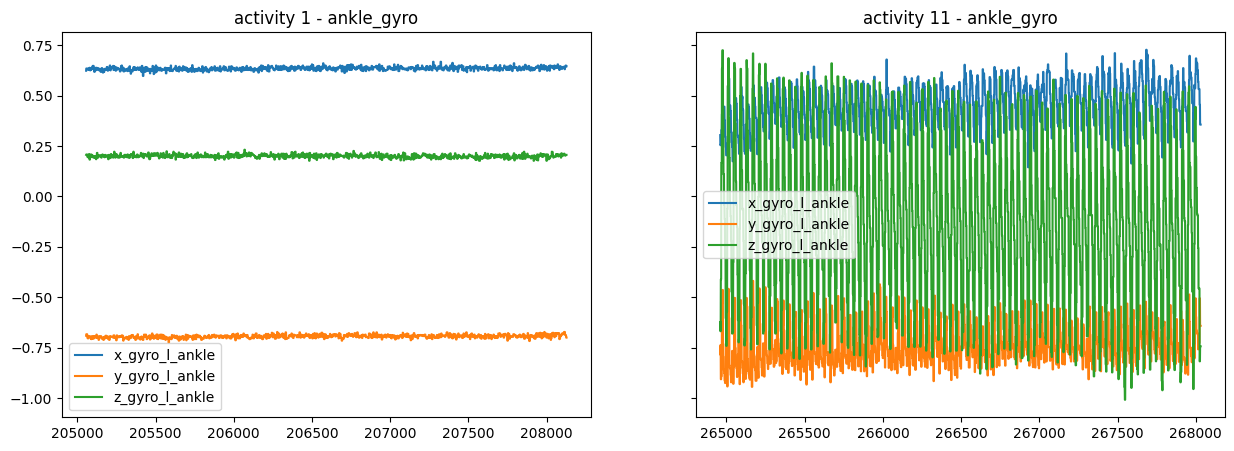

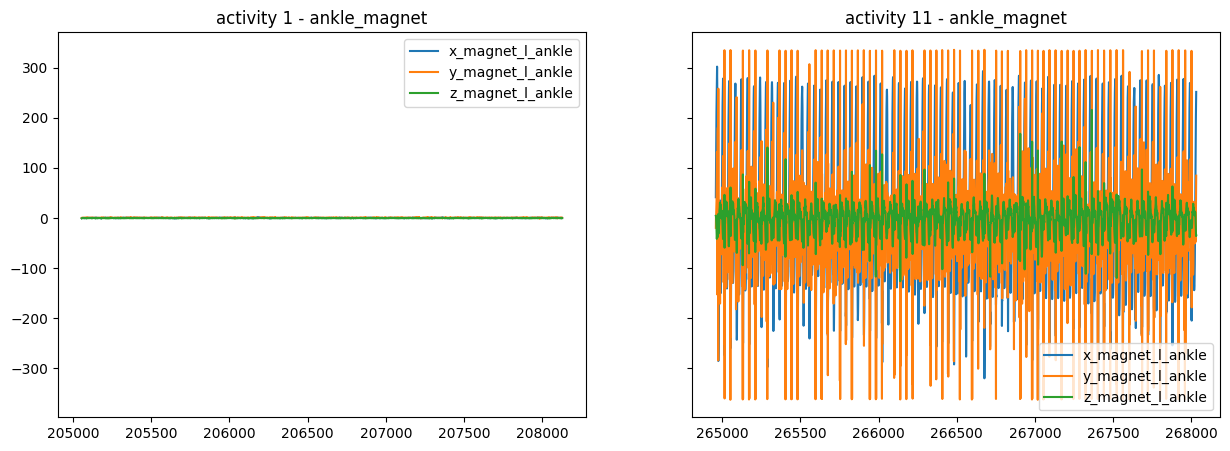

In [23]:
subject_id = 1

for group, measurements in ankle_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    ankle_subset = ankle_df[columns]
    
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey = True)

    for i, activity in enumerate([1, 11]):
        ankle_subsubset = ankle_subset[(ankle_subset["activity_label"] == activity) & (ankle_subset["subject_id"] == subject_id)]
        axes[i].plot(ankle_subsubset[measurements])
        axes[i].legend(measurements)
        axes[i].set_title(f"activity {activity} - {group}")

#### To Summarize

Not only does the sensor data manifest differently according to the sensor type, it also manifests differently according to body part and activity. Making the filter too aggressive may wash out the data for low or high intensity activity, and making the filter too permissive may not smooth or clean the data efficiently. 

One way I can address these discrepancies is to apply the Butterworth filter to the data according to the activity, which would probably be the most comprehensive method. However, it's not very replicable, nor is it time efficient. 

Instead, I'll keep the filters at certain cut off frequencies but use the difference (noise) as a feature. Intuitively, I'd expect the noise to be relatively low for the "standing still" activity compared to the "running" or "jumping" activity. This gives me the chance to transform this filtering issue into a useful feature for my model. 

| **Sensor** | **Filter Type** | **Cutoff Frequency (fc)** |                  **Goal**                  |
|:----------:|:---------------:|:-------------------------:|:------------------------------------------:|
|    Accel   |     Low-Pass    |            12 Hz           |       Remove device rattle/vibration       |
|    Gyro    |     Low-Pass    |            12 Hz           |        Smooth out rotational "noise"       |
|   Magnet   |     Low-Pass    |           2 Hz          | Stabilize orientation against interference |
|     ECG    |    Band-Pass    |        [0.5, 24] Hz       |     Isolate the R-peak and remove drift    |

#### Applying the Filter

In [4]:
filter_specs = {
        "accel": {
            "type": "low",
            "fc": 12
        },
        "gyro": {
            "type": "low",
            "fc": 12
        },
        "magnet": {
            "type": "low",
            "fc": 2
        },
        "ecg": {
            "type": "band",
            "fc": [0.5, 24]
        }
    } 

def apply_butterworth(data, filter_type, fc, fs = 50):
    nyq = 0.5 * fs

    if isinstance(fc, list):
        normal_cutoff = [c / nyq for c in fc]
    else: 
        normal_cutoff = fc / nyq

    b, a = butter(N = 4, Wn = normal_cutoff, btype = filter_type, analog = False)
    y = filtfilt(b, a, data)
    return y

# Phase 1: Preprocess the whole dataframe
def preprocess_full_df(df, fs = 50):
    """
    Processes subject by subject to prevent signal bleeding between subjects.
    """
    for sensor, specs in filter_specs.items():
        cols = [col for col in df.columns if sensor in col]
        for col in cols: 
            filtered_signal = apply_butterworth(df[col], specs["type"], specs["fc"], fs)

            if "ecg" in col:
                mean = filtered_signal.mean()
                std = filtered_signal.std()

                df[f"{col}_filt"] = filtered_signal / np.max(np.abs(filtered_signal))
            else:
                df[f"{col}_filt"] = filtered_signal
    
    return df
            

In [5]:
# Phase 2: Window the clean data
def window_generator(df, window_size = 250, step_size = 125):
    """
    Function yields chunks of the dataframe by subject and by activity.
    """
    for subject_id in df["subject_id"].unique():
        subj_df = df[df["subject_id"] == subject_id].reset_index()

        for activity_label in subj_df["activity_label"].unique():
            subj_activity_df = subj_df[subj_df["activity_label"] == activity_label].reset_index()

            if len(subj_activity_df) < window_size: 
                continue

            for start in range(0, len(subj_activity_df) - window_size + 1, step_size):
                yield subj_activity_df.iloc[start : start + window_size]



In [263]:
# Filter whole dataset (test)
df_filtered = preprocess_full_df(df)

In [ ]:
df_filtered.info()

In [ ]:
df_filtered[['x_accel_l_ankle', 'x_accel_l_ankle_filt']]

In [28]:
arm_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "arm" in group]

# Include only standing still and running activities
arm_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]


In [ ]:
subject_id = 1

for group, measurements in arm_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    arm_subset = arm_df[columns]
    arm_filt_subset = arm_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = arm_subset[(arm_subset["activity_label"] == activity) & (arm_subset["subject_id"] == subject_id)]
        filt_data = arm_filt_subset[(arm_filt_subset["activity_label"] == activity) & (arm_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

In [30]:
chest_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "chest" in group]

# Include only standing still and running activities
chest_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]

In [ ]:
subject_id = 1

for group, measurements in chest_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    chest_subset = chest_df[columns]
    chest_filt_subset = chest_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = chest_subset[(chest_subset["activity_label"] == activity) & (chest_subset["subject_id"] == subject_id)]
        filt_data = chest_filt_subset[(chest_filt_subset["activity_label"] == activity) & (chest_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

In [32]:
ankle_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "ankle" in group]

# Include only standing still and running activities
ankle_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]

In [ ]:
subject_id = 1

for group, measurements in ankle_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    ankle_subset = ankle_df[columns]
    ankle_filt_subset = ankle_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = ankle_subset[(ankle_subset["activity_label"] == activity) & (ankle_subset["subject_id"] == subject_id)]
        filt_data = ankle_filt_subset[(ankle_filt_subset["activity_label"] == activity) & (ankle_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

In [ ]:
subject_id = 1

ecg_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "ecg" in group]

ecg_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]
ecg_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]

for group, measurements in ecg_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    ecg_subset = ecg_df[columns]
    ecg_filt_subset = ecg_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = ecg_subset[(ecg_subset["activity_label"] == activity) & (ecg_subset["subject_id"] == subject_id)]
        filt_data = ecg_filt_subset[(ecg_filt_subset["activity_label"] == activity) & (ecg_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

In [ ]:
for subject_id in df_filtered.subject_id.unique():
    ecg_subject_subset_1 = df_filtered[(df_filtered["activity_label"] == 1) & (df_filtered["subject_id"] == subject_id)]
    ecg_subject_subset_11 = df_filtered[(df_filtered["activity_label"] == 11) & (df_filtered["subject_id"] == subject_id)]

    fig, axes = plt.subplots(2, 1, figsize = (30, 10))
    axes[0].plot(ecg_subject_subset_1["ecg_l2_filt"])
    axes[0].set_title(f"subject {subject_id} - activity 1")
    axes[1].plot(ecg_subject_subset_11["ecg_l2_filt"])
    axes[1].set_title(f"subject {subject_id} - activity 11")

    plt.show()

#### Power Spectral Density Plots

In [ ]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['x_accel_l_ankle'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("m / s^2")
ax1.psd(df_filtered['x_accel_l_ankle'], NFFT = 512, Fs = 50)

plt.show()

In [ ]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['x_accel_l_ankle_filt'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("m / s^2")
ax1.psd(df_filtered['x_accel_l_ankle_filt'], NFFT = 512, Fs = 50)

plt.show()

In [ ]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['ecg_l1'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("m / s^2")
ax1.psd(df_filtered['ecg_l1'], NFFT = 512, Fs = 50)

plt.show()

In [ ]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['ecg_l1_filt'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("mV")
ax1.psd(df_filtered['ecg_l1_filt'], NFFT = 512, Fs = 50)

plt.show()

In [61]:
print(data_groups)
print(data_groups.keys())

{'chest_acceleration': ['x_accel_chest', 'y_accel_chest', 'z_accel_chest'], 'ecg': ['ecg_l1', 'ecg_l2'], 'ankle_acceleration': ['x_accel_l_ankle', 'y_accel_l_ankle', 'z_accel_l_ankle'], 'ankle_gyro': ['x_gyro_l_ankle', 'y_gyro_l_ankle', 'z_gyro_l_ankle'], 'ankle_magnet': ['x_magnet_l_ankle', 'y_magnet_l_ankle', 'z_magnet_l_ankle'], 'arm_acceleration': ['x_accel_r_arm', 'y_accel_r_arm', 'z_accel_r_arm'], 'arm_gyro': ['x_gyro_r_arm', 'y_gyro_r_arm', 'z_gyro_r_arm'], 'arm_magnet': ['x_magnet_r_arm', 'y_magnet_r_arm', 'z_magnet_r_arm']}
dict_keys(['chest_acceleration', 'ecg', 'ankle_acceleration', 'ankle_gyro', 'ankle_magnet', 'arm_acceleration', 'arm_gyro', 'arm_magnet'])


## 5. Label Engineering

The next part of the preparation is to execute label engineering. That is, to extract the heart rate from ECG readings, and calculate subject-wise thresholds in order to re-classify the null class. 

In [6]:
def calculate_tilt(window, sensor):    
    x = window[f"x_{sensor}_filt"].mean()
    y = window[f"y_{sensor}_filt"].mean()
    z = window[f"z_{sensor}_filt"].mean()

    mag = np.sqrt(x**2 + y**2 + z**2)

    if mag == 0:
        return 0
    
    tilt = np.degrees(np.arccos(np.clip(y / mag, -1.0, 1.0)))

    return tilt

In [16]:
def extract_ar_coeffs(window, sensor, order = 3):
    if (len(window[sensor]) <= order) or (np.std(window[sensor]) < 1e-6):
        return [0.0] * order
    
    try:
        model = AutoReg(window[sensor], lags = order).fit()
        return model.params[1:]
    
    except:
        return np.nan

In [8]:
def consolidate_bpm(df):
    df["bpm_final"] = df["bpm_l1"]

    l2_is_healthy = (df["bpm_l2"] > 52) & (df["bpm_l2"].notna())
    l1_is_healthy = (df["bpm_l1"] > 52) & (df["bpm_l1"].notna())

    df.loc[l1_is_healthy & l2_is_healthy, "bpm_final"] = (df["bpm_l1"] + df["bpm_l2"]) / 2

    # If L1 failed but L2 is good:
    df.loc[~l1_is_healthy & l2_is_healthy, "bpm_final"] = df["bpm_l2"]

    df["bpm_final"] = df["bpm_final"].fillna(70)

    return df

In [9]:
def extract_hr_features(df, fs = 50, threshold = [1.05, 1.02]):
    """
    Extracts HR from ECG measurements subject by subject to prevent signal bleeding between subjects.
    """
    df = df.copy()

    qrs_refrac_time = 200 # ms
    n_samp_qrs_refrac = round(qrs_refrac_time * fs / 1000.)

    for i, lead in enumerate(["ecg_l1_filt", "ecg_l2_filt"]):
        bpm_col = f"bpm_{lead.split('_')[-2]}"

        signal = np.abs(df[lead])

        th = signal.mean() + (threshold[i] * signal.std())

        peaks, _ = find_peaks(signal, height = th, distance = n_samp_qrs_refrac)

        if len(peaks) > 1: 
            rr_seconds = np.diff(peaks) / fs
            hr_values = 60 / rr_seconds

            hr_values = np.clip(hr_values, 50, 220)

            df[bpm_col] = np.nan

            df.iloc[peaks[1:], df.columns.get_loc(bpm_col)] = hr_values

            df[bpm_col] = df[bpm_col].interpolate(method = "linear").ffill().bfill()
        
        else:
            df[bpm_col] = np.nan

    return consolidate_bpm(df)

In [284]:
def plot_ecg_signal(time, signal):
    fig = plt.figure(figsize = (20, 3))
    ax = plt.axes()
    ax.plot(time, signal)
    min_t = int(np.min(time))
    max_t = int(np.max(time))
    major_ticks = np.arange(min_t, max_t + 1, 50)
    ax.set_xticks(major_ticks)
    ax.grid(which = "major", linestyle = "-", color = "red", linewidth = "0.5")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    return ax

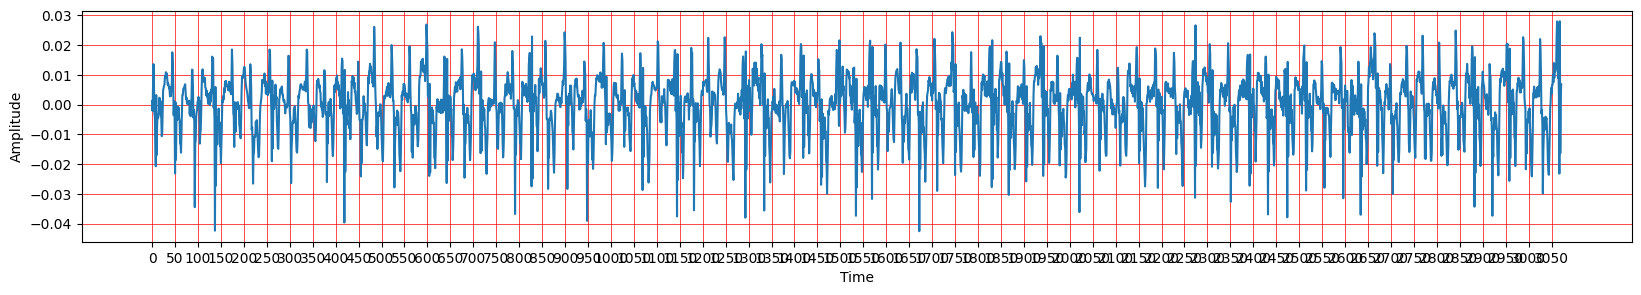

In [323]:
ecg_example = df_filtered[(df_filtered["activity_label"] == 1)] # | (df_filtered["activity_label"] == 11)]

ecg_example_1 = ecg_example[ecg_example["subject_id"] == 0]
ecg_example_1.reset_index(inplace = True)

plot_ecg_signal(ecg_example_1.index, ecg_example_1["ecg_l2_filt"])
plt.show()

In [300]:
qrs_refrac_time = 200 # ms
n_samp_qrs_refrac = round(qrs_refrac_time * 50 / 1000.)

def find_r_peaks(time, signal, threshold=0.6, distance=n_samp_qrs_refrac):
    smax = np.max(signal)
    smin = np.min(signal)
    srange = smax - smin
    th = srange * threshold + smin
    r_peaks, _ = find_peaks(signal > th, height=0, distance=distance)
    peak_times = time[r_peaks]
    peak_values = signal[r_peaks]
    return peak_times, peak_values

peak_times, peak_values = find_r_peaks(ecg_example_1.index, ecg_example_1["ecg_l1_filt"])

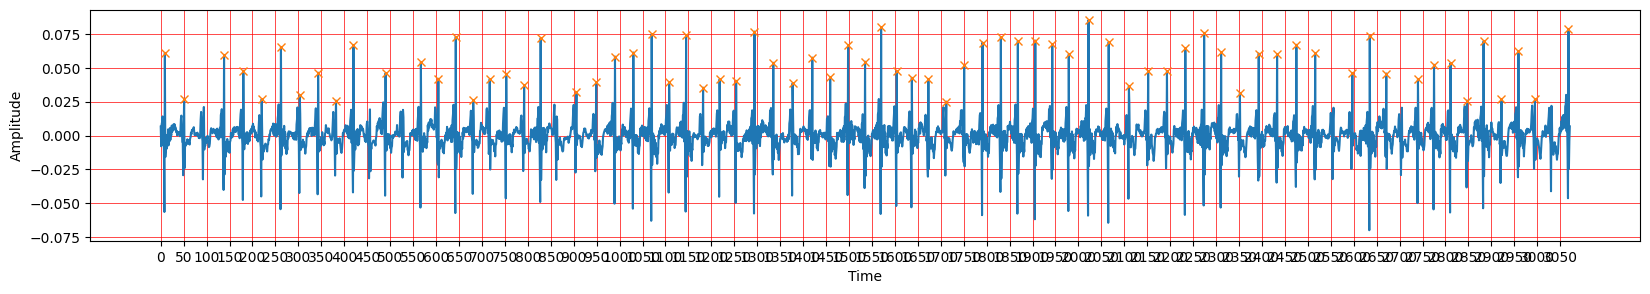

In [301]:
ax = plot_ecg_signal(ecg_example_1.index, ecg_example_1["ecg_l1_filt"])
ax.plot(peak_times, peak_values, 'x')
plt.show()

In [340]:
df_with_hr = df_filtered.groupby("subject_id", group_keys = False).apply(extract_hr_features, include_groups = True)

C:\Users\steven\AppData\Local\Temp\ipykernel_29932\758355019.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_with_hr = df_filtered.groupby("subject_id", group_keys = False).apply(extract_hr_features, include_groups = True)


In [347]:
df_with_hr[df_with_hr["subject_id"] == 5][["bpm_l1", "bpm_l2"]]

,bpm_l1,bpm_l2
649497,150.0,150.000000
649498,150.0,150.000000
649499,150.0,150.000000
649500,150.0,150.000000
649501,150.0,150.000000
...,...,...
747796,300.0,272.727273
747797,300.0,272.727273
747798,300.0,272.727273
747799,300.0,272.727273


<Axes: xlabel='Time', ylabel='Amplitude'>

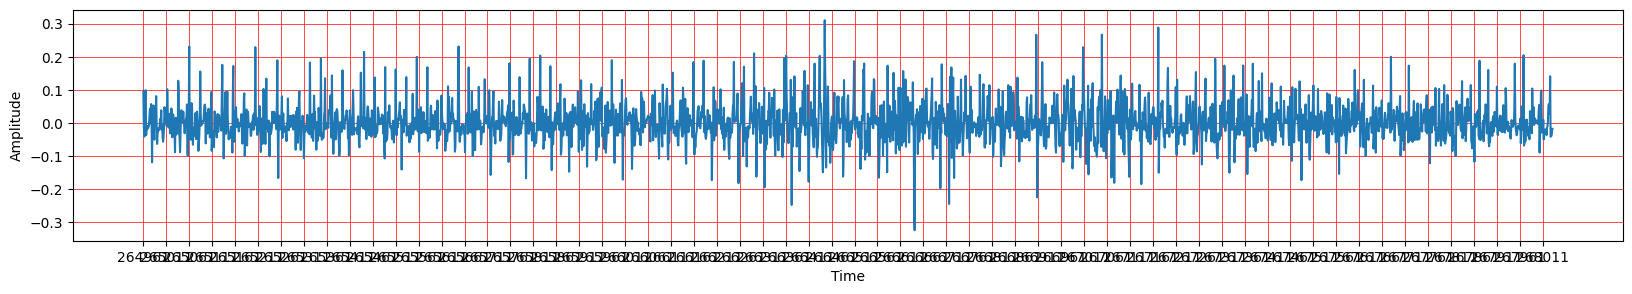

In [286]:
hr_example = df_with_hr[(df_with_hr["activity_label"] == 11)] # | (df_with_hr["activity_label"] == 11)]

hr_example_1 = hr_example[hr_example["subject_id"] == 1]

plot_ecg_signal(hr_example_1["id"], hr_example_1["ecg_l1_filt"])

In [78]:
# Draft
def calculate_sma_draft(window_df, sensor):
    data_keys = [group for group in data_groups.keys() if "ecg" not in group]

    df = df.copy()

    for data_key in data_keys:
        key_col = f"{data_key}_sma"
        total = 0
        smas = []

        for id in df.id:
            total += (math.abs(df[data_groups[data_key]][0]) + math.abs(df[data_groups[data_key]][1]) + math.abs(df[data_groups[data_key]][2]))
            smas.append(total / id)
    
        df[key_col] = smas
    
    return df
        

In [17]:
# Final
def calculate_sma(window_df, sensor):
    cols = [c for c in window_df.columns if sensor in c and any(a in c for a in ["x_", "y_", "z_"]) and any(b in c for b in ["_filt"])]

    sma = window_df[cols].abs().sum(axis = 1).mean()

    return sma

### Final "Master" Pipeline

#### Calculating Subject-Wise Thresholds and Re-Classifying the Null Class

As a reminder, this was the logic for null class re-classification:

| **Motion Intensity (accel SMA)** | **Heart Rate** | **Classification** |                               **Logic**                              |
|:----------------------------:|:--------------:|:------------------:|:--------------------------------------------------------------------:|
|              Low             |       Low      |   Baseline (Idle)  |                 True Null: Sitting or standing still.                |
|             High             |       Low      |    Sensor Noise    |       False Exertion: Moving the sensor, but no cardio load.       |
|              Low             |      High      |      Recovery      | Afterburn: Heart rate is still high, but movement has stopped. |
|             High             |      High      |   Active Exertion  |           True Workout: Validates the High Exertion class.           |

In [11]:
def calculate_subject_baselines(df, rest_labels = [1, 2, 3]):
    baselines = {}

    for subject_id in df["subject_id"].unique():
        rest_data = df[
            (df["subject_id"] == subject_id) & 
            (df["activity_label"].isin(rest_labels))
        ]

        if not rest_data.empty:
            baselines[subject_id] = rest_data["bpm_l1"].quantile(0.1)
        else:
            baselines[subject_id] = df["bpm_l1"].quantile(0.1)
    
    return baselines
    

In [18]:
# Step 1: Preprocess by subject
df_filtered = df.groupby("subject_id", group_keys = False).apply(preprocess_full_df, include_groups = True)

# Step 2: Extract HR by subject and activity to prevent bleeding between activity-subject pairs
df_final = df_filtered.groupby(["subject_id", "activity_label"], group_keys = False).apply(
    extract_hr_features,
    include_groups = True
)

C:\Users\steven\AppData\Local\Temp\ipykernel_42072\1048014463.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df.groupby("subject_id", group_keys = False).apply(preprocess_full_df, include_groups = True)
C:\Users\steven\AppData\Local\Temp\ipykernel_42072\1048014463.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final = df_filtered.groupby(["subject_id", "activity_label"], group_key

In [13]:
df_final["bpm_final"].describe()

count    1.211745e+06
mean     1.111744e+02
std      3.279655e+01
min      5.000000e+01
25%      8.847837e+01
50%      1.054944e+02
75%      1.301169e+02
max      2.200000e+02
Name: bpm_final, dtype: float64

In [14]:
df_final["bpm_final"].value_counts()

bpm_final
107.142857    22353
103.448276    17977
100.000000    17288
120.000000    15141
111.111111    14582
              ...  
71.230790         1
69.750589         1
68.270389         1
66.790188         1
65.309988         1
Name: count, Length: 413331, dtype: int64

In [23]:
# Step 3: Feature Extraction Loop
subject_baselines = calculate_subject_baselines(df_final)

feature_rows = []

sma_threshold = 25
hr_delta_threshold = 25

for window in window_generator(df_final):
    subject = window["subject_id"].iloc[0]
    original_label = window["activity_label"].iloc[0]
    avg_l1_bpm = window["bpm_l1"].mean()
    avg_l2_bpm = window["bpm_l2"].mean()
    avg_bpm = (avg_l1_bpm + avg_l2_bpm) / 2
    hr_elevation = avg_bpm - subject_baselines.get(subject, 70)

    motion_sma = calculate_sma(window, "accel_l_ankle")

    chest_accel_ta = calculate_tilt(window, "accel_chest")
    ankle_accel_ta = calculate_tilt(window, "accel_l_ankle")
    arm_accel_ta = calculate_tilt(window, "accel_r_arm")

    chest_accel_sma = calculate_sma(window, "accel_chest")
    ankle_accel_sma = motion_sma
    arm_accel_sma = calculate_sma(window, "accel_r_arm")

    ankle_gyro_sma = calculate_sma(window, "gyro_l_ankle")
    arm_gyro_sma = calculate_sma(window, "gyro_r_arm")

    chest_x_ar_features = extract_ar_coeffs(window, "x_accel_chest_filt")
    chest_y_ar_features = extract_ar_coeffs(window, "y_accel_chest_filt")
    chest_z_ar_features = extract_ar_coeffs(window, "z_accel_chest_filt")
    ankle_x_ar_features = extract_ar_coeffs(window, "x_accel_l_ankle_filt")
    ankle_y_ar_features = extract_ar_coeffs(window, "y_accel_l_ankle_filt")
    ankle_z_ar_features = extract_ar_coeffs(window, "z_accel_l_ankle_filt")
    arm_x_ar_features = extract_ar_coeffs(window, "x_accel_r_arm_filt")
    arm_y_ar_features = extract_ar_coeffs(window, "y_accel_r_arm_filt")
    arm_z_ar_features = extract_ar_coeffs(window, "z_accel_r_arm_filt")


    if original_label == 0:
        is_motion_high = motion_sma > sma_threshold
        is_hr_high = hr_elevation > hr_delta_threshold

        if not is_motion_high and not is_hr_high:
            new_label = 0 # Baseline
        elif is_motion_high and not is_hr_high:
            new_label = 101 # Sensor Noise
        elif not is_motion_high and is_hr_high:
            new_label = 102 # Recovery
        elif is_motion_high and is_hr_high:
            new_label = 103 # Active Exertion
    
    else:
        new_label = original_label

    features = {
        # Identifiers
        "subject_id": subject,
        "label": new_label,

        # Physiology 
        "avg_bpm": avg_bpm,
        "hr_elevation": hr_elevation,

        # Tilt
        "chest_accel_ta": chest_accel_ta,
        "ankle_accel_ta": ankle_accel_ta,
        "arm_accel_ta": arm_accel_ta,

        # AR Coefficients (only on accelerator measurements)
        "ar_1": chest_x_ar_features.iloc[0],
        "ar_2": chest_x_ar_features.iloc[1],
        "ar_3": chest_x_ar_features.iloc[2],
        "ar_4": chest_y_ar_features.iloc[0],
        "ar_5": chest_y_ar_features.iloc[1],
        "ar_6": chest_y_ar_features.iloc[2],
        "ar_7": chest_z_ar_features.iloc[0],
        "ar_8": chest_z_ar_features.iloc[1],
        "ar_9": chest_z_ar_features.iloc[2],

        "ar_10": ankle_x_ar_features.iloc[0],
        "ar_11": ankle_x_ar_features.iloc[1],
        "ar_12": ankle_x_ar_features.iloc[2],
        "ar_13": ankle_y_ar_features.iloc[0],
        "ar_14": ankle_y_ar_features.iloc[1],
        "ar_15": ankle_y_ar_features.iloc[2],
        "ar_16": ankle_z_ar_features.iloc[0],
        "ar_17": ankle_z_ar_features.iloc[1],
        "ar_18": ankle_z_ar_features.iloc[2],

        "ar_19": arm_x_ar_features.iloc[0],
        "ar_20": arm_x_ar_features.iloc[1],
        "ar_21": arm_x_ar_features.iloc[2],
        "ar_22": arm_y_ar_features.iloc[0],
        "ar_23": arm_y_ar_features.iloc[1],
        "ar_24": arm_y_ar_features.iloc[2],
        "ar_25": arm_z_ar_features.iloc[0],
        "ar_26": arm_z_ar_features.iloc[1],
        "ar_27": arm_z_ar_features.iloc[2],

        # Intensity (SMA)
        "chest_accel_sma": chest_accel_sma,
        "ankle_accel_sma": ankle_accel_sma,
        "arm_accel_sma": arm_accel_sma,

        "ankle_gyro_sma":  ankle_gyro_sma,
        "arm_gyro_sma": arm_gyro_sma,

        # Variance
        "chest_x_accel_std": window["x_accel_chest_filt"].std(),
        "chest_y_accel_std": window["y_accel_chest_filt"].std(),
        "chest_z_accel_std": window["z_accel_chest_filt"].std(),

        "ankle_x_accel_std": window["x_accel_l_ankle_filt"].std(),
        "ankle_y_accel_std": window["y_accel_l_ankle_filt"].std(),
        "ankle_z_accel_std": window["z_accel_l_ankle_filt"].std(),

        "arm_x_accel_std": window["x_accel_r_arm_filt"].std(),
        "arm_y_accel_std": window["y_accel_r_arm_filt"].std(),
        "arm_z_accel_std": window["z_accel_r_arm_filt"].std(),
    }

    feature_rows.append(features)

feature_df = pd.DataFrame(feature_rows)

In [24]:
display(feature_df)

,subject_id,label,avg_bpm,hr_elevation,chest_accel_ta,ankle_accel_ta,arm_accel_ta,ar_1,ar_2,ar_3,...,arm_gyro_sma,chest_x_accel_std,chest_y_accel_std,chest_z_accel_std,ankle_x_accel_std,ankle_y_accel_std,ankle_z_accel_std,arm_x_accel_std,arm_y_accel_std,arm_z_accel_std
0,0,0,63.978205,0.025017,88.068844,169.433324,113.014979,1.851507,-1.653538,0.713082,...,1.521589,0.094552,0.154698,0.279008,0.194977,0.076221,0.246343,0.153468,0.245503,0.212431
1,0,0,62.972290,-0.980898,86.516730,169.912717,113.130197,1.756124,-1.577969,0.705556,...,1.619803,0.098118,0.248367,0.203618,0.107733,0.079931,0.275237,0.119649,0.200073,0.268058
2,0,0,64.478972,0.525784,85.531853,169.954601,113.306680,1.716566,-1.572595,0.742088,...,1.686143,0.094572,0.089266,0.139647,0.068657,0.077829,0.109568,0.100079,0.128663,0.088782
3,0,0,56.639414,-7.313774,86.223065,169.932464,121.372780,1.823369,-1.640999,0.678834,...,1.643632,0.131794,0.204486,0.135638,0.544044,0.317948,0.392180,2.047049,2.062880,0.993229
4,0,0,50.765179,-13.188010,87.088196,168.901263,144.864971,1.804135,-1.605180,0.651052,...,1.576495,0.140375,0.209634,0.173945,0.578670,0.321942,0.398448,2.538808,2.330743,1.022800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9488,9,12,129.758017,73.888557,89.317567,154.723187,121.345254,2.341366,-2.066401,0.688991,...,1.714722,10.365489,1.804495,5.206464,5.491165,7.561732,6.801011,9.421497,6.588526,4.105634
9489,9,12,132.462451,76.592990,91.869423,155.960232,121.416422,2.321755,-2.037020,0.672153,...,1.716605,10.039979,1.451832,4.930454,5.275446,7.538346,7.555847,9.526031,6.154295,3.383764
9490,9,12,135.838715,79.969254,90.648111,159.067889,120.568197,2.292265,-1.995237,0.653638,...,1.703578,10.052832,1.520595,5.109187,4.919357,7.849286,7.653612,9.786523,6.416507,3.854300
9491,9,12,138.805195,82.935734,91.687081,157.185085,119.953814,2.318301,-2.047973,0.681059,...,1.701101,10.205328,1.911141,5.340433,5.213327,7.740290,7.386892,9.747728,6.428784,3.718039


In [25]:
feature_df["ar_6"].describe()

count    9493.000000
mean        0.723320
std         0.071317
min        -0.074618
25%         0.686243
50%         0.728848
75%         0.769357
max         1.205032
Name: ar_6, dtype: float64

In [26]:
display(feature_df[feature_df["label"] == 101])

,subject_id,label,avg_bpm,hr_elevation,chest_accel_ta,ankle_accel_ta,arm_accel_ta,ar_1,ar_2,ar_3,...,arm_gyro_sma,chest_x_accel_std,chest_y_accel_std,chest_z_accel_std,ankle_x_accel_std,ankle_y_accel_std,ankle_z_accel_std,arm_x_accel_std,arm_y_accel_std,arm_z_accel_std


In [64]:
display(feature_df[(feature_df["label"] == 103)])

,subject_id,label,avg_bpm,hr_elevation,chest_accel_ta,ankle_accel_ta,arm_accel_ta,ar_1,ar_2,ar_3,...,arm_gyro_sma,chest_x_accel_std,chest_y_accel_std,chest_z_accel_std,ankle_x_accel_std,ankle_y_accel_std,ankle_z_accel_std,arm_x_accel_std,arm_y_accel_std,arm_z_accel_std
565,0,103,173.847854,109.894666,94.412645,151.298056,119.385913,0.657716,-1.964747,2.275908,...,1.672475,10.054063,3.274452,3.431641,8.988391,6.909953,8.413365,10.890938,13.239416,6.489645
566,0,103,167.438764,103.485576,87.710775,151.971470,105.011121,0.640049,-1.942345,2.272259,...,1.701021,9.847029,3.301898,3.444511,9.831690,7.055796,7.466469,10.808477,12.465952,6.399951
567,0,103,179.242379,115.289191,82.694978,153.873391,80.889661,0.656544,-1.965289,2.281117,...,1.763688,9.373443,3.155398,3.118781,9.743990,6.847285,6.386463,10.005306,8.934633,6.165066
1845,1,103,180.438995,121.214198,92.523578,148.145974,140.568562,0.610674,-1.998427,2.366291,...,1.559671,9.302279,2.837138,2.836982,4.578857,6.289254,9.566264,11.123969,10.207732,7.129251
1871,1,103,178.886281,119.661484,93.557305,149.170127,144.255678,0.280417,-1.337569,2.015030,...,1.648880,9.456336,2.765330,2.213702,4.065825,6.990226,9.863756,11.048485,9.451231,6.856478
2584,2,103,133.268608,71.790627,89.330919,161.425269,128.727973,0.566681,-1.857201,2.255328,...,1.592696,10.020392,3.283351,3.279463,5.438779,6.973620,9.731496,9.205063,9.453419,4.653655
2649,2,103,163.419063,101.941083,90.706469,159.856350,139.357155,0.534098,-1.791305,2.202527,...,1.732069,10.869104,5.634745,4.501179,6.720103,9.108052,13.052908,13.548069,11.812055,7.885188
2650,2,103,182.680173,121.202192,93.071065,158.072674,125.565702,0.534410,-1.785543,2.196166,...,1.729003,10.901408,5.222335,4.343776,6.118546,8.795848,12.562399,11.852689,12.398281,4.993718
2651,2,103,184.486333,123.008352,93.115273,157.358712,118.920504,0.624242,-1.967756,2.302513,...,1.703842,10.661111,4.688304,4.184843,5.513186,8.571081,11.445460,11.246143,12.279040,4.860737
2652,2,103,178.555447,117.077466,90.862728,159.403611,116.989892,0.628275,-1.972395,2.304049,...,1.648293,10.567616,4.975294,4.271042,5.470634,8.389373,11.048071,10.789975,11.655445,6.119372


In [27]:
display(feature_df[(feature_df["label"] == 12) & (feature_df["subject_id"] == 6)])

,subject_id,label,avg_bpm,hr_elevation,chest_accel_ta,ankle_accel_ta,arm_accel_ta,ar_1,ar_2,ar_3,...,arm_gyro_sma,chest_x_accel_std,chest_y_accel_std,chest_z_accel_std,ankle_x_accel_std,ankle_y_accel_std,ankle_z_accel_std,arm_x_accel_std,arm_y_accel_std,arm_z_accel_std
6671,6,12,146.522665,90.133440,87.895267,163.518862,145.246310,2.231103,-1.986890,0.704989,...,1.756090,10.497429,3.800441,5.069744,4.272609,7.098097,7.854992,5.622965,8.928487,4.854140
6672,6,12,142.370501,85.981276,91.318492,164.601760,147.929597,2.237225,-1.986515,0.699441,...,1.717126,10.250668,2.995118,5.467597,4.428294,7.393727,8.297168,5.058365,8.843179,4.531949
6673,6,12,141.742031,85.352806,93.173747,167.310282,148.964005,2.231522,-1.970541,0.687845,...,1.714400,10.059290,2.694067,5.390196,4.523887,7.499578,8.222436,4.529811,8.905387,4.228562
6674,6,12,142.435065,86.045840,91.602407,164.529610,154.150113,2.229107,-1.964369,0.682005,...,1.725588,10.086379,2.503551,5.375138,4.209353,7.441598,7.948175,4.178063,8.889045,3.965211
6675,6,12,143.440816,87.051591,92.362189,163.556239,157.527114,2.245015,-1.971273,0.674264,...,1.732050,10.025459,2.596933,5.262775,3.740404,7.412609,7.909468,3.179329,8.799003,3.601886
6676,6,12,144.214463,87.825238,92.148230,167.136298,148.671959,2.262569,-1.979146,0.666538,...,1.766069,10.025690,2.644051,5.105068,3.712147,7.194130,7.412047,3.984450,8.763562,3.937318
6677,6,12,144.642239,88.253014,89.085999,164.518112,158.698059,2.257321,-1.977456,0.669395,...,1.729606,10.402084,2.618800,5.580049,4.645447,7.226481,7.910701,4.178464,8.977989,3.817020


In [28]:
feature_df.label.value_counts()

label
102    4532
0      2356
1       230
4       230
3       230
5       230
9       230
11      230
10      230
2       228
7       221
8       219
6       208
12       70
103      49
Name: count, dtype: int64

## 6. Data Splitting

In [29]:
train_subs = [0, 1, 2, 3, 4]
val_subs = [5, 6]
test_subs = [7, 8, 9]

final_feature_df = feature_df[feature_df["label"] != 101]

X_train_full = final_feature_df[final_feature_df["subject_id"].isin(train_subs)].drop(columns = ["label", "subject_id"])
y_train_full = final_feature_df[final_feature_df["subject_id"].isin(train_subs)]["label"]
groups = final_feature_df[final_feature_df["subject_id"].isin(train_subs)]["subject_id"]


## 7. Modeling & Clustering

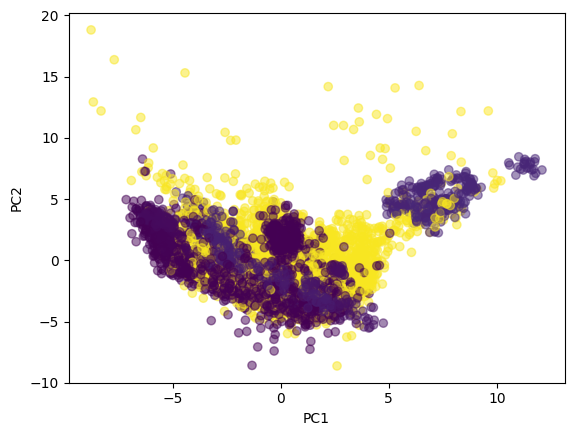

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_full)

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c = y_train_full, cmap = "viridis", alpha = 0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [31]:
gkf = GroupKFold(n_splits = 3)

clf = RandomForestClassifier(
    n_estimators = 100,
    class_weight = "balanced",
    random_state = 42
)

exertion_map = {
    "103": 2, # active exertion
    "102": 0, # recovery
    "0": 0, # baseline
    "1": 0, # standing
    "2": 0, # sitting
    "3": 0, # lying down
    "4": 1, # walking
    "5": 1, # climbing stairs
    "6": 1, # waist bends forward
    "7": 1, # frontal elevation of arms
    "8": 1, # knees bending (crouching)
    "9": 2, # cycling
    "10": 2, # jogging
    "11": 2, # running
    "12": 2 # jumping
}

y_train_clustered = y_train_full.astype(str).map(exertion_map)

for train_idx, val_idx in gkf.split(X_train_full, y_train_clustered, groups = groups):
    X_train_raw, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train_raw, y_val = y_train_clustered.iloc[train_idx], y_train_clustered.iloc[val_idx]

    sm = SMOTE(random_state = 42, k_neighbors = 3)
    X_train, y_train = sm.fit_resample(X_train_raw, y_train_raw)

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    print(f"results for fold with subjects: {groups.iloc[val_idx].unique()}")
    print(classification_report(y_val, y_pred))

results for fold with subjects: [0]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1073
           1       0.66      0.36      0.46       118
           2       1.00      0.61      0.76        79

    accuracy                           0.90      1270
   macro avg       0.85      0.65      0.72      1270
weighted avg       0.89      0.90      0.89      1270

results for fold with subjects: [1 3]
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1543
           1       0.60      0.51      0.55       240
           2       0.95      0.61      0.74       156

    accuracy                           0.86      1939
   macro avg       0.81      0.69      0.74      1939
weighted avg       0.86      0.86      0.86      1939

results for fold with subjects: [2 4]
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1497
           1     

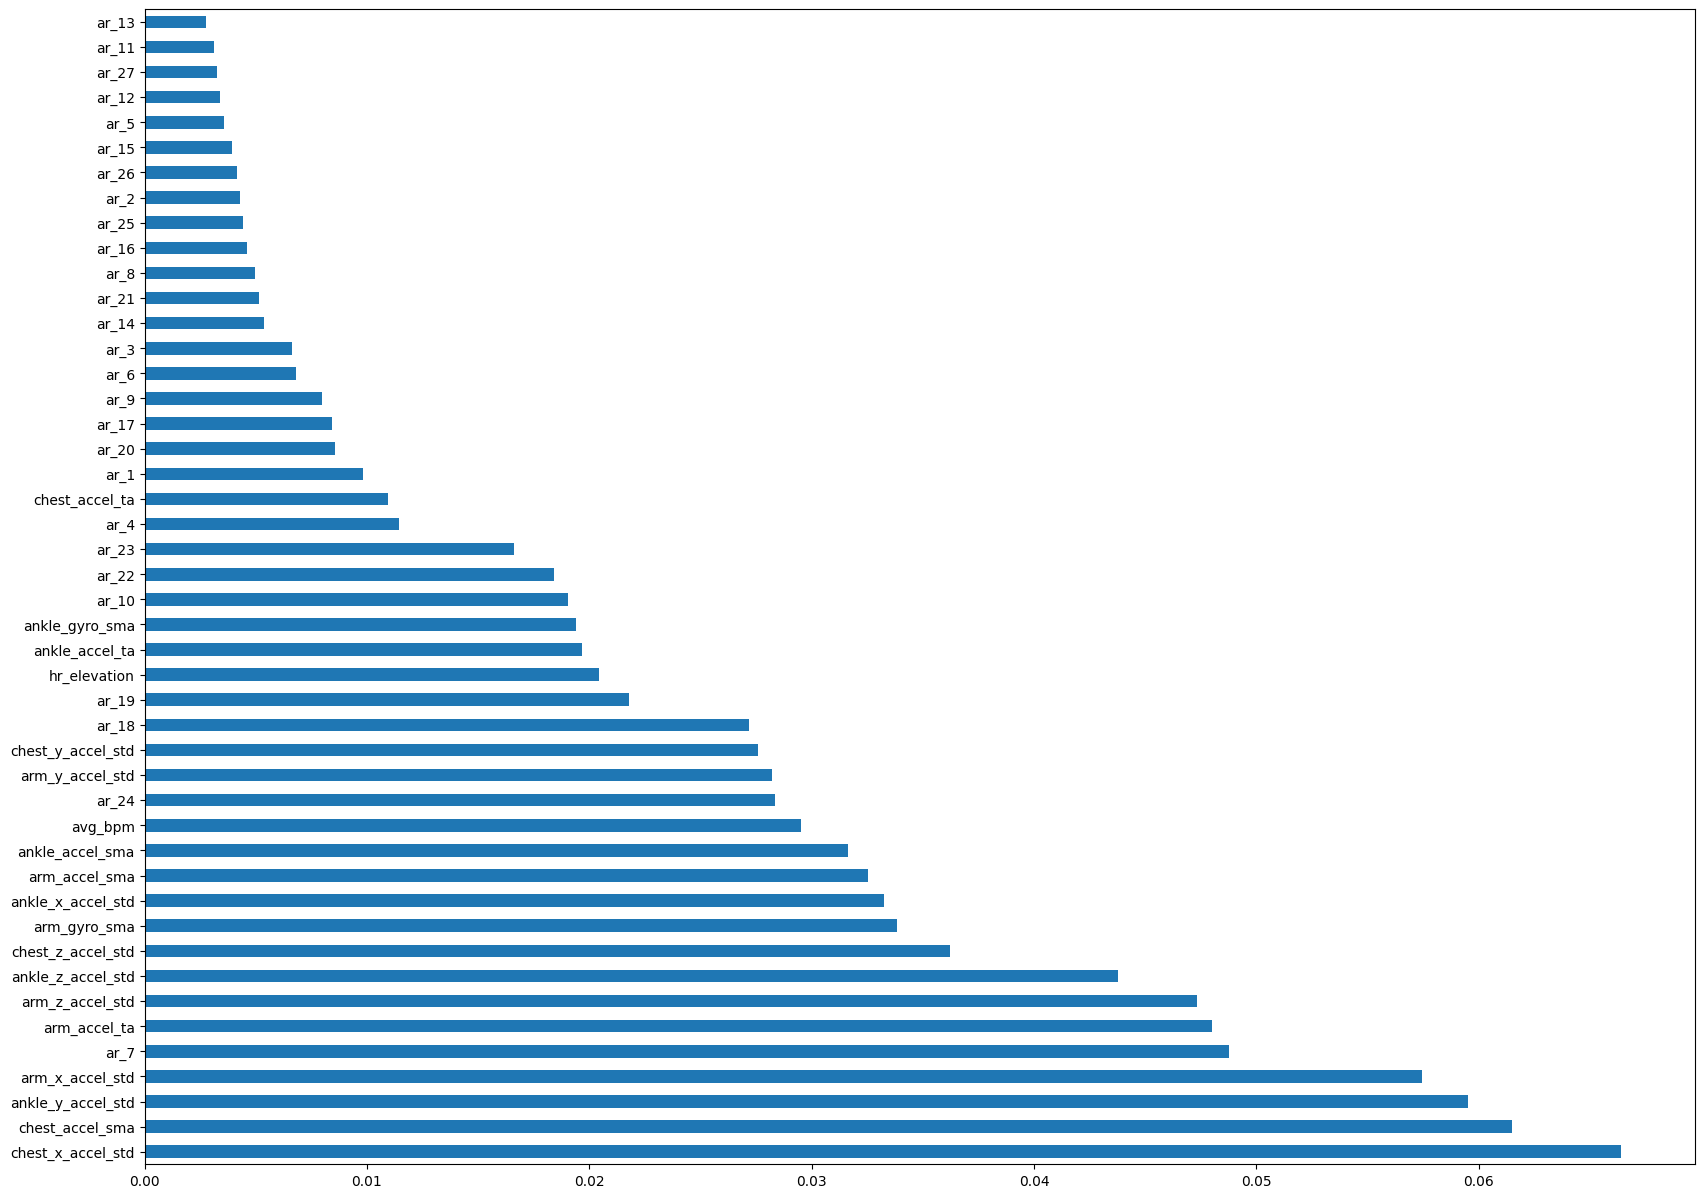

In [63]:
importances = pd.Series(clf.feature_importances_, index=X_train.columns)
plt.figure(figsize = (20, 15))
importances.nlargest(50).plot(kind='barh')
plt.show()

# remaining workflow: 

1. Preprocessing: load data -> butterworth / filtfilt -> calculate magnitudes & SMA
2. Label engineering: extract HR -> calculate subject-wise thresholds -> re-classify null class
3. Data splitting: split into train/val/test
4. Modeling & clustering: dimensionality reduction -> supervised training -> evaluation
5. Synthesis: qualitative interpretation via LLM 